# Limpieza — faltantes, outliers y duplicados

**Qué hace este notebook.** Toma `dataframefinal.csv` (salida de `Unificacion.ipynb`), diagnostica tres problemas de calidad que el EDA inicial deja abiertos y agrega columnas de *flags*. **No borra ninguna fila ni modifica ningún valor existente**: sigue el criterio del resto del repo de separar detectar de corregir.

| Bloque | Pregunta | Columnas nuevas |
|---|---|---|
| 2. Faltantes | ¿Qué falta, por qué, y qué hacemos con cada variable? Caso crítico: `Rentabilidad_Neta_Zona` | `Flag_Rentabilidad_No_Calculable`, `Motivo_Rentabilidad_Nula` y las columnas de tratamiento de 2.6 (`*_Limpio`, `*_Tratada`, `Rentabilidad_Neta_Cascada`) |
| 3. Outliers | ¿Hay precios imposibles *en contexto* (relativos a su barrio y tipo) que el filtro global p1–p99 no ve? | `Ratio_Precio_m2_vs_Mediana`, `Flag_Precio_m2_Muy_Bajo`, `Flag_Precio_m2_Muy_Alto` |
| 4. Duplicados | ¿Hay el mismo inmueble publicado más de una vez con distinto `Item_ID`? | `Grupo_Duplicado`, `Duplicado_Nivel`, `Flag_Duplicado_Sobrante` |

**Entrada:** `data/processed/dataframefinal.csv` · **Salida:** `data/processed/dataframe_limpio.csv` (mismas filas, columnas nuevas).

> Los umbrales y las decisiones marcadas como **PROPUESTA** son para discutir en el grupo; están como parámetros al inicio de cada celda para poder cambiarlos y volver a correr. Lo que el README ya reconoce como limitación (cobertura de alquiler, tipo de cambio fijo, pesos del Score como supuesto) no se repite acá: se agrega lo que el README no cuantifica.

## 1. Carga

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)

NAVY, TEAL, BROWN = "#323B66", "#508198", "#5A4F4F"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 110})


def encontrar_raiz_repo(inicio=None):
    """Sube por el árbol de directorios hasta encontrar la raíz del repositorio."""
    actual = (inicio or Path.cwd()).resolve()
    for carpeta in [actual, *actual.parents]:
        if (carpeta / ".git").exists():
            return carpeta
    raise FileNotFoundError("No se encontró la raíz del repositorio. Ejecutá el notebook desde dentro de la copia local del repo.")


RAIZ = encontrar_raiz_repo()
RUTA_ENTRADA = RAIZ / "data" / "processed" / "dataframefinal.csv"
RUTA_SALIDA = RAIZ / "data" / "processed" / "dataframe_limpio.csv"

if not RUTA_ENTRADA.exists():
    raise FileNotFoundError(f"Falta {RUTA_ENTRADA.name}. Ejecutá primero data/processed/Unificacion.ipynb.")

df = pd.read_csv(RUTA_ENTRADA, low_memory=False)
COLUMNAS_ORIGINALES = list(df.columns)
print("Filas:", len(df), "| Columnas:", df.shape[1])
print(df["Tipo_Operacion"].value_counts().to_string())

Filas: 55582 | Columnas: 88
Tipo_Operacion
Venta       50639
Alquiler     4943


## 2. Faltantes

### 2.1 Panorama general

43 de 88 columnas tienen al menos un nulo; 45 no tienen ninguno.
Columnas con más de 5% de nulos: 17


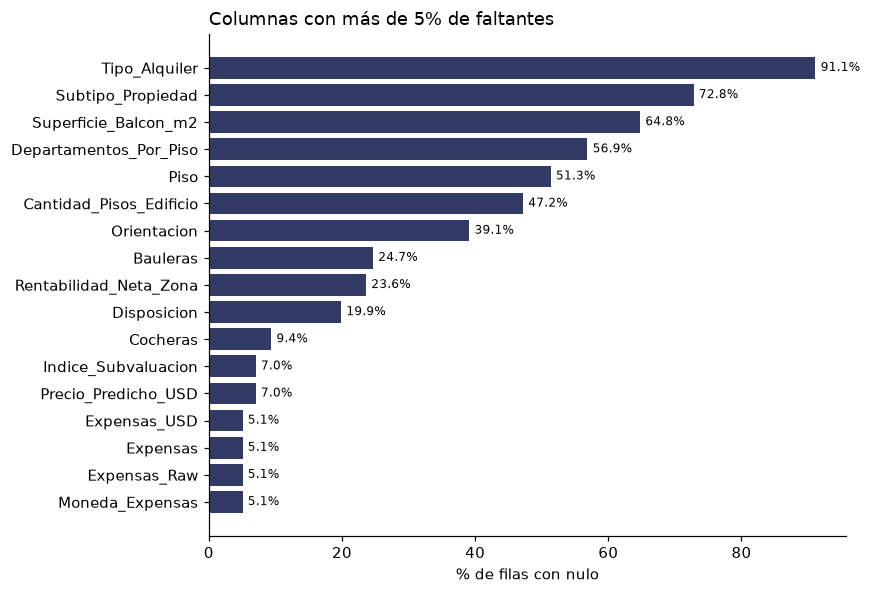

In [15]:
nulos = (
    pd.DataFrame({"n_nulos": df.isna().sum(), "pct_nulo": df.isna().mean() * 100})
    .query("n_nulos > 0")
    .sort_values("pct_nulo", ascending=False)
)
print(f"{len(nulos)} de {df.shape[1]} columnas tienen al menos un nulo; {df.shape[1] - len(nulos)} no tienen ninguno.")
print(f"Columnas con más de 5% de nulos: {(nulos.pct_nulo > 5).sum()}")

top = nulos[nulos.pct_nulo > 5].iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(top.index, top.pct_nulo, color=NAVY)
for y, v in enumerate(top.pct_nulo):
    ax.text(v + 0.8, y, f"{v:.1f}%", va="center", fontsize=8)
ax.set_xlabel("% de filas con nulo")
ax.set_title("Columnas con más de 5% de faltantes", loc="left")
plt.tight_layout()
plt.show()

**Lectura:** 43 de las 88 columnas tienen algún nulo y 17 superan el 5%. La cifra engaña si se la toma como un único problema: casi todas las columnas del extremo superior son nulos *estructurales* (la variable no existe para ese tipo de aviso) y no huecos de carga. Eso se separa en el punto siguiente.

### 2.2 ¿Faltan porque *no aplica* o porque *no se informó*?

La pregunta que cambia la decisión es si el nulo es estructural (la variable no existe para ese tipo de aviso) o un hueco real. Se mira la tasa de nulos según operación y tipo de propiedad.

In [16]:
VARS_FALTANTES = ["Tipo_Alquiler", "Subtipo_Propiedad", "Superficie_Balcon_m2", "Departamentos_Por_Piso",
                  "Piso", "Cantidad_Pisos_Edificio", "Orientacion", "Bauleras", "Disposicion", "Cocheras", "Expensas_USD"]

por_operacion = df.groupby("Tipo_Operacion")[VARS_FALTANTES].agg(lambda s: s.isna().mean() * 100).T.round(1)
por_tipo = df.groupby("Tipo_Propiedad")[VARS_FALTANTES].agg(lambda s: s.isna().mean() * 100).T.round(1)

print("% de nulos por tipo de operación")
display(por_operacion)
print("% de nulos por tipo de propiedad")
display(por_tipo)

% de nulos por tipo de operación


Tipo_Operacion,Alquiler,Venta
Tipo_Alquiler,0.0,100.0
Subtipo_Propiedad,67.7,73.3
Superficie_Balcon_m2,67.1,64.5
Departamentos_Por_Piso,59.6,56.6
Piso,51.2,51.4
Cantidad_Pisos_Edificio,57.5,46.2
Orientacion,40.2,39.0
Bauleras,9.3,26.2
Disposicion,13.3,20.5
Cocheras,6.6,9.6


% de nulos por tipo de propiedad


Tipo_Propiedad,Casa,Departamento,PH
Tipo_Alquiler,97.2,90.1,94.0
Subtipo_Propiedad,89.8,69.0,89.1
Superficie_Balcon_m2,100.0,56.7,100.0
Departamentos_Por_Piso,100.0,47.0,100.0
Piso,100.0,42.9,79.7
Cantidad_Pisos_Edificio,32.1,41.5,100.0
Orientacion,53.9,35.5,55.2
Bauleras,87.4,9.7,91.8
Disposicion,100.0,10.2,35.0
Cocheras,0.0,0.0,85.8


**Lectura:**
- **No aplica.** `Tipo_Alquiler` es nulo en el 100% de las ventas y en 0% de los alquileres. En las casas, `Piso`, `Departamentos_Por_Piso`, `Superficie_Balcon_m2` y `Disposicion` son 100% nulos; en los PH lo son `Departamentos_Por_Piso`, `Superficie_Balcon_m2` y `Cantidad_Pisos_Edificio`. Hablar de piso en una casa no tiene sentido: no hay nada que imputar.
- **Hueco real, en departamentos.** Donde la variable sí aplica, falta: `Piso` 42,9%, `Departamentos_Por_Piso` 47,0%, `Superficie_Balcon_m2` 56,7%, `Orientacion` 35,5%. Esa cobertura limita su uso como variable explicativa general.
- **Expensas** es casi completa en alquiler (0,8% de nulos) y razonable en venta (5,5%). Su problema no es el nulo sino el flag de anomalía (~43%), ya tratado en `Unificacion.ipynb`.
- Algo no cierra: **`Cocheras` tiene 0% de nulos en Casa y Departamento pero 85,8% en PH.** Se revisa en 2.3.

### 2.3 Faltantes que `isna()` no ve, y codificaciones inconsistentes

Tres revisiones puntuales: valores centinela escritos como texto (`"Desconocido"`), cómo se codifica `Cocheras` según el tipo de propiedad, y si `Superficie_Balcon_m2` nulo significa *no tiene* o *no informó*.

In [17]:
# (a) Valores centinela escritos como texto: no figuran como nulos
CENTINELAS = {"desconocido", "n/a", "na", "sin dato", "no informado", "none", "nan", "s/d", "-", ""}
filas = []
for col in df.select_dtypes(include=["object", "string"]).columns:
    s = df[col].dropna().astype(str).str.strip().str.lower()
    n = int(s.isin(CENTINELAS).sum())
    if n:
        filas.append({"Columna": col, "Filas con centinela": n, "% del dataset": n / len(df) * 100})
display(pd.DataFrame(filas).set_index("Columna").round(1))

alq = df[df.Tipo_Operacion == "Alquiler"]
print("Tipo_Alquiler dentro de los alquileres:")
print(alq["Tipo_Alquiler"].value_counts().to_frame("avisos").assign(pct=lambda t: (t.avisos / len(alq) * 100).round(1)).to_string())

# (b) Cocheras: ¿cómo se codifica "no tiene" según el tipo de propiedad?
print("\nCocheras por tipo de propiedad:")
display(df.groupby("Tipo_Propiedad")["Cocheras"].agg(
    informadas="count", nulos=lambda s: int(s.isna().sum()), ceros=lambda s: int((s == 0).sum()),
    con_cochera=lambda s: int((s > 0).sum())))

# (c) Superficie_Balcon_m2 vs. la variable dicotómica Balcon (departamentos)
dep = df[df.Tipo_Propiedad == "Departamento"]
print("Departamentos: % con Superficie_Balcon_m2 nula, según el flag Balcon")
display(dep.groupby("Balcon")["Superficie_Balcon_m2"].agg(avisos="size", pct_nulo=lambda s: s.isna().mean() * 100).round(1))

# (d) Test de precios para el supuesto "Cocheras nulo en PH = no tiene":
# si los nulos fueran ceros, deberían parecerse a los "sin cochera" y valer menos que los "con cochera" (como pasa en departamentos).
vta = df[(df.Tipo_Operacion == "Venta") & df.Precio_m2_USD.notna()].copy()
vta["rel_barrio"] = vta["Precio_m2_USD"] / vta.groupby(["Tipo_Propiedad", "Barrio_Normalizado"])["Precio_m2_USD"].transform("median")
vta["cochera_grupo"] = np.where(vta.Cocheras.isna(), "nulo", np.where(vta.Cocheras > 0, "con cochera", "cochera = 0"))
print("\nPrecio/m² relativo a la mediana de su barrio (ventas, dentro de cada tipo) según Cocheras:")
display(vta.pivot_table(index="Tipo_Propiedad", columns="cochera_grupo", values="rel_barrio", aggfunc="median").round(3))
print("Avisos por grupo:")
display(vta.pivot_table(index="Tipo_Propiedad", columns="cochera_grupo", values="rel_barrio", aggfunc="size").fillna(0).astype(int))

,Filas con centinela,% del dataset
Columna,,
Tipo_Alquiler,4489,8.1
Estado_Inmueble,41894,75.4


Tipo_Alquiler dentro de los alquileres:
               avisos   pct
Tipo_Alquiler              
Desconocido      4489  90.8
Tradicional       239   4.8
Temporario        215   4.3

Cocheras por tipo de propiedad:


,informadas,nulos,ceros,con_cochera
Tipo_Propiedad,,,,
Casa,4300,0,1552,2748
Departamento,45219,3,36652,8567
PH,859,5201,0,859


Departamentos: % con Superficie_Balcon_m2 nula, según el flag Balcon


,avisos,pct_nulo
Balcon,,
0,16820,80.4
1,28402,42.7



Precio/m² relativo a la mediana de su barrio (ventas, dentro de cada tipo) según Cocheras:


cochera_grupo,cochera = 0,con cochera,nulo
Tipo_Propiedad,,,
Casa,0.984,1.004,NaN
Departamento,0.982,1.089,0.871
PH,NaN,0.963,1.005


Avisos por grupo:


cochera_grupo,cochera = 0,con cochera,nulo
Tipo_Propiedad,,,
Casa,1414,2588,0
Departamento,32869,7508,3
PH,0,801,4794


**Lectura:**
- **Faltantes disfrazados.** `Estado_Inmueble` tiene 41.894 filas con el texto "Desconocido" (75,4% del dataset) y `Tipo_Alquiler` 4.489, que son el **90,8% de los alquileres**: solo 239 están confirmados como tradicionales y 215 como temporarios. `isna()` no ve ninguno de los dos. Consecuencia práctica: no se puede filtrar "alquiler tradicional" como pide el alcance del proyecto; se asume por defecto y hay que declararlo.
- **`Cocheras` está codificada distinto según el tipo.** En Casa y Departamento, "no tiene" figura como 0 (1.552 y 36.652 ceros). En PH no hay ningún cero: 859 informadas, todas con cochera, y 5.201 nulas. Hay dos lecturas posibles: si los nulos son ceros, el 14,2% de los PH tiene cochera (859 de 6.060), cerca del 18,9% de los departamentos; si son huecos reales, todos los PH informados tienen cochera. **El test de precios no resuelve la duda.** En departamentos, la cochera se asocia a un precio por m² 11% por encima de la mediana de su barrio (1,089 contra 0,982 sin cochera); en casas casi no se nota (1,004 contra 0,984); y en PH los que tienen cochera (0,963) no valen más que los nulos (1,005). Como en PH la cochera no muestra ningún premio, el test no puede distinguir entre las dos lecturas: ni respalda ni refuta imputar 0. Por eso **no se imputa por defecto** (2.6.3). Importa porque **H2 habla de cochera**.
- **`Superficie_Balcon_m2` mezcla dos situaciones.** Entre los departamentos con `Balcon = 0`, el 80,4% tiene la superficie nula (es un "no tiene"), pero el 19,6% restante informa una superficie igual: una contradicción dentro del mismo aviso. Con `Balcon = 1`, el 42,7% no informa la superficie: ahí sí es un hueco real.

### 2.4 El caso crítico: `Rentabilidad_Neta_Zona`

Es un KPI central y tiene ~24% de nulos. La rentabilidad se calcula por celda **Barrio × Tipo × Ambientes** y exige `MIN_N = 5` avisos de venta **y** 5 de alquiler en esa celda, más expensas válidas. Se replica esa lógica para asignar a cada aviso el motivo exacto de su nulo.

In [18]:
GRANO = ["Barrio_Normalizado", "Tipo_Propiedad", "Ambientes_Agrupado"]
MIN_N = 5  # mismo umbral que Unificacion.ipynb

# Punto 7 del grupo: en PH y casas los ceros de expensas cuentan en la mediana de la celda. Poner True SOLO cuando el
# Unificacion.ipynb que generó dataframefinal.csv incluya ese cambio; si no coincide, falla el control de réplica de 2.6.5.
UNIFICACION_CUENTA_CEROS_PH_CASA = True
cero_real_ph_casa = (df["Tipo_Propiedad"].isin(["PH", "Casa"]) & (df["Expensas_USD"] == 0)) if UNIFICACION_CUENTA_CEROS_PH_CASA else pd.Series(False, index=df.index)

# Mismo filtro de calidad de precio que Unificacion.ipynb
mask_flags_ok = (
    (df["Flag_Precio_Anomalo"] == 0) & (df["Flag_Operacion_Anomala"] == 0)
    & (df["Flag_Superficie_Anomala"] == 0) & (df["Superficie_Total_m2"] > 0)
)
mask_precio_ok = mask_flags_ok & df["Precio_m2_USD"].between(df["p1_m2"], df["p99_m2"])
base_mask = mask_precio_ok & df["Barrio_Normalizado"].notna() & df["Ambientes_Agrupado"].notna()
expensas_mask = (
    ((df["Flag_Expensas_Anomalas"] == 0) | cero_real_ph_casa) & df["Expensas_USD"].notna()
    & df["Barrio_Normalizado"].notna() & df["Ambientes_Agrupado"].notna()
)

todas_las_celdas = df.dropna(subset=GRANO).groupby(GRANO).size().index
celdas = pd.DataFrame(index=todas_las_celdas)
celdas["n_ventas"] = df[base_mask & (df.Tipo_Operacion == "Venta")].groupby(GRANO).size()
celdas["n_alquileres"] = df[base_mask & (df.Tipo_Operacion == "Alquiler")].groupby(GRANO).size()
celdas["n_expensas"] = df[expensas_mask].groupby(GRANO).size()
celdas = celdas.fillna(0).astype(int)


def estado_celda(r):
    faltan_v, faltan_a = r.n_ventas < MIN_N, r.n_alquileres < MIN_N
    if faltan_v and faltan_a:
        return "Faltan ventas y alquileres (<5 c/u)"
    if faltan_a:
        return "Faltan alquileres (<5)"
    if faltan_v:
        return "Faltan ventas (<5)"
    if r.n_expensas == 0:
        return "Sin expensas válidas"
    return "Calculable"


celdas["estado"] = celdas.apply(estado_celda, axis=1)

# Motivo por aviso
aviso = df[GRANO + ["Tipo_Operacion", "Rentabilidad_Neta_Zona"]].join(celdas["estado"], on=GRANO)
sin_clave = df["Barrio_Normalizado"].isna() | df["Ambientes_Agrupado"].isna()
df["Motivo_Rentabilidad_Nula"] = np.where(
    df["Rentabilidad_Neta_Zona"].notna(), "Calculada",
    np.where(sin_clave, "Sin barrio o ambientes", aviso["estado"]),
)
df["Flag_Rentabilidad_No_Calculable"] = df["Rentabilidad_Neta_Zona"].isna().astype(int)

# Control: el motivo "Calculable" debe coincidir exactamente con tener rentabilidad
coincide = (aviso["estado"].eq("Calculable") == df["Rentabilidad_Neta_Zona"].notna())[~sin_clave].mean()
print(f"Control de réplica vs. Unificacion.ipynb: coincide en {coincide:.2%} de los avisos con barrio y ambientes")

venta = df[df.Tipo_Operacion == "Venta"]
print("\nMotivo del nulo en Rentabilidad_Neta_Zona (solo ventas):")
print(venta["Motivo_Rentabilidad_Nula"].value_counts().to_frame("avisos").assign(pct=lambda t: (t.avisos / len(venta) * 100).round(1)).to_string())

Control de réplica vs. Unificacion.ipynb: coincide en 100.00% de los avisos con barrio y ambientes

Motivo del nulo en Rentabilidad_Neta_Zona (solo ventas):
                                     avisos   pct
Motivo_Rentabilidad_Nula                         
Calculada                             38005  75.1
Faltan alquileres (<5)                11537  22.8
Sin barrio o ambientes                  922   1.8
Faltan ventas y alquileres (<5 c/u)     175   0.3


**Lectura:** el 25,7% de las ventas sin rentabilidad se explica casi por completo por **falta de alquileres en la celda** (22,8 puntos: 11.537 avisos). Los otros motivos pesan poco: avisos sin barrio o ambientes 1,8%, celdas sin expensas válidas 0,7% y celdas sin ventas ni alquileres suficientes 0,3%. La réplica de la lógica de `Unificacion.ipynb` coincide en el 100% de los avisos, así que el diagnóstico es exacto, no una aproximación. Es un problema de **oferta de alquileres**, no de calidad del dato.

% de ventas SIN rentabilidad, por tipo de propiedad:
Tipo_Propiedad
Casa            80.6
Departamento    12.1
PH              76.3



Barrios sin NINGUNA venta con rentabilidad: 11 de 48


,ventas,alquileres,pct_ventas_con_rentabilidad
Barrio_Normalizado,,,
Villa General Mitre,4,0,0.0
Villa Riachuelo,53,1,0.0
Villa Santa Rita,134,2,0.0
Agronomía,175,7,0.0
Vélez Sarsfield,253,7,0.0
Villa Real,119,9,0.0
Villa Soldati,146,9,0.0
Versalles,213,10,0.0
Nueva Pompeya,240,12,0.0


Cobertura en los barrios de la hipótesis H1:


,ventas,alquileres,pct_ventas_con_rentabilidad
Barrio_Normalizado,,,
Flores,2344,162,88.0
Parque Avellaneda,440,20,0.0
Mataderos,1085,47,41.0
Palermo,2262,531,98.0
Recoleta,2088,498,95.0
Belgrano,2198,454,94.0


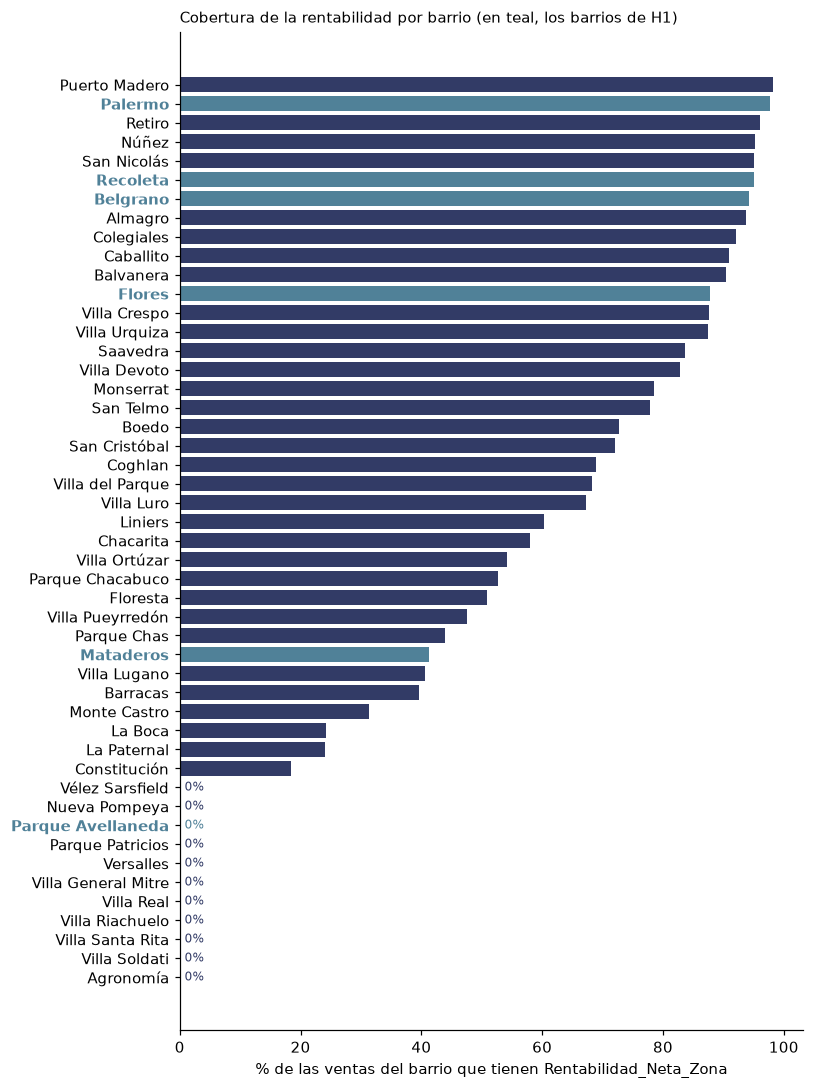

In [19]:
# Cobertura por tipo de propiedad y por barrio (ventas)
print("% de ventas SIN rentabilidad, por tipo de propiedad:")
print((venta.groupby("Tipo_Propiedad")["Rentabilidad_Neta_Zona"].agg(lambda s: s.isna().mean() * 100)).round(1).to_string())

barrios = pd.DataFrame({
    "ventas": venta.groupby("Barrio_Normalizado").size(),
    "alquileres": df[df.Tipo_Operacion == "Alquiler"].groupby("Barrio_Normalizado").size(),
    "pct_ventas_con_rentabilidad": venta.groupby("Barrio_Normalizado")["Rentabilidad_Neta_Zona"].agg(lambda s: s.notna().mean() * 100),
}).fillna({"alquileres": 0})
barrios["alquileres"] = barrios["alquileres"].astype(int)

sin_rent = barrios[barrios.pct_ventas_con_rentabilidad == 0].sort_values("alquileres")
print(f"\nBarrios sin NINGUNA venta con rentabilidad: {len(sin_rent)} de {len(barrios)}")
display(sin_rent.round(0))

# Barrios que menciona H1
H1_SUR_OESTE = ["Flores", "Parque Avellaneda", "Mataderos"]
H1_NORTE = ["Palermo", "Recoleta", "Belgrano"]
print("Cobertura en los barrios de la hipótesis H1:")
display(barrios.loc[H1_SUR_OESTE + H1_NORTE].round(0))

b = barrios.sort_values("pct_ventas_con_rentabilidad")
fig, ax = plt.subplots(figsize=(7.5, 10))
colores = [TEAL if x in H1_SUR_OESTE + H1_NORTE else NAVY for x in b.index]
ax.barh(b.index, b.pct_ventas_con_rentabilidad, color=colores)
for y, (barrio, v) in enumerate(zip(b.index, b.pct_ventas_con_rentabilidad)):
    if v == 0:
        ax.text(0.8, y, "0%", va="center", fontsize=8, color=TEAL if barrio in H1_SUR_OESTE + H1_NORTE else NAVY)
for lbl in ax.get_yticklabels():
    if lbl.get_text() in H1_SUR_OESTE + H1_NORTE:
        lbl.set_color(TEAL)
        lbl.set_fontweight("bold")
ax.set_xlabel("% de las ventas del barrio que tienen Rentabilidad_Neta_Zona")
ax.set_title("Cobertura de la rentabilidad por barrio (en teal, los barrios de H1)", loc="left", fontsize=10)
plt.tight_layout()
plt.show()

**Lectura:** el nulo está concentrado. **El 89,6% de las casas y el 76,3% de los PH** no tienen rentabilidad, contra 12,1% de los departamentos. Y 11 de los 48 barrios no tienen ninguna venta con rentabilidad: en ellos hay entre 0 y 20 alquileres en total (Parque Avellaneda, el que más, 20).

Esto afecta a **H1**, que compara el sur y oeste contra el norte. La cobertura es de 94% a 98% en Belgrano, Recoleta y Palermo, pero de 88% en Flores, **41% en Mataderos y 0% en Parque Avellaneda**. Si H1 se prueba tal cual, el lado "sur/oeste" se evalúa sobre una fracción de sus avisos y no sobre el barrio completo. Hay que declararlo en la hipótesis o resolverlo.

In [20]:
# ¿Cuántos de esos barrios se recuperarían con una cascada más gruesa (Barrio x Tipo, o solo Barrio)?
def barrios_recuperables(columnas):
    v = df[base_mask & (df.Tipo_Operacion == "Venta")].groupby(columnas).size()
    a = df[base_mask & (df.Tipo_Operacion == "Alquiler")].groupby(columnas).size()
    ok = pd.concat([v, a], axis=1, keys=["v", "a"]).fillna(0)
    return ok[(ok.v >= MIN_N) & (ok.a >= MIN_N)]


for nombre, cols in [("Barrio x Tipo", ["Barrio_Normalizado", "Tipo_Propiedad"]), ("solo Barrio", ["Barrio_Normalizado"])]:
    ok = barrios_recuperables(cols)
    barrios_ok = set(ok.index.get_level_values("Barrio_Normalizado"))
    rec = [b for b in sin_rent.index if b in barrios_ok]
    quedan = [b for b in sin_rent.index if b not in barrios_ok]
    print(f"Nivel {nombre}: se recuperan {len(rec)} de {len(sin_rent)} barrios -> {rec}")
    print(f"   siguen sin rentabilidad: {quedan}")

Nivel Barrio x Tipo: se recuperan 4 de 11 barrios -> ['Vélez Sarsfield', 'Nueva Pompeya', 'Parque Patricios', 'Parque Avellaneda']
   siguen sin rentabilidad: ['Villa General Mitre', 'Villa Riachuelo', 'Villa Santa Rita', 'Agronomía', 'Villa Real', 'Villa Soldati', 'Versalles']
Nivel solo Barrio: se recuperan 8 de 11 barrios -> ['Agronomía', 'Vélez Sarsfield', 'Villa Real', 'Villa Soldati', 'Versalles', 'Nueva Pompeya', 'Parque Patricios', 'Parque Avellaneda']
   siguen sin rentabilidad: ['Villa General Mitre', 'Villa Riachuelo', 'Villa Santa Rita']


**Lectura:** una cascada más gruesa recupera parte del problema, a costa de comparar cosas menos parecidas. Agrupando por Barrio × Tipo (sin ambientes) se recuperan 4 de los 11 barrios (Vélez Sarsfield, Nueva Pompeya, Parque Patricios y Parque Avellaneda); agrupando solo por Barrio, 8 de 11. Villa General Mitre, Villa Riachuelo y Villa Santa Rita quedan sin rentabilidad en cualquier nivel (0, 1 y 2 alquileres en todo el barrio).

La cascada es la misma idea que ya usa el Índice de Subvaluación (4 niveles, solo ~7% de nulos), pero acá el costo es mayor: mezclar monoambientes con unidades de 4+ ambientes en un mismo barrio distorsiona el alquiler por m². La cascada está implementada como columna experimental en 2.6.5. **Decisión del grupo (6/10):** H1 se evalúa solo en los barrios con rentabilidad calculada en el nivel original (se acota), y la cascada queda como prueba de robustez.

### 2.5 ¿Qué tan confiable es la rentabilidad que sí se calcula?

La rentabilidad de cada celda sale de la **mediana de pocos alquileres**: el umbral mínimo es 5. Se mira cuántos alquileres respaldan cada celda y si las celdas más rentables son justamente las de muestra más chica.

In [21]:
cel = celdas[["n_ventas", "n_alquileres"]].copy()
rent_celda = df.dropna(subset=["Rentabilidad_Neta_Zona"]).groupby(GRANO)["Rentabilidad_Neta_Zona"].first()
cel = cel.join(rent_celda, how="inner")
cel["muestra_chica"] = cel["n_alquileres"] < 10

print(f"Celdas (Barrio x Tipo x Ambientes) con rentabilidad: {len(cel)}")
print("Alquileres por celda:", cel["n_alquileres"].describe().round(1).to_dict())
print(f"Celdas apoyadas en 5 a 9 alquileres: {int(cel.muestra_chica.sum())} ({cel.muestra_chica.mean()*100:.0f}%)")

umbral_top = cel["Rentabilidad_Neta_Zona"].quantile(0.9)
en_top = cel["Rentabilidad_Neta_Zona"] >= umbral_top
print(f"Rentabilidad neta de las celdas: mediana {cel.Rentabilidad_Neta_Zona.median():.3f} | percentil 90 {umbral_top:.3f}")
print(f"\n% de celdas con muestra chica -> en el 10% más rentable: {cel[en_top].muestra_chica.mean()*100:.0f}% | en el resto: {cel[~en_top].muestra_chica.mean()*100:.0f}%")
print(f"Desvío de la rentabilidad -> celdas con muestra chica: {cel[cel.muestra_chica].Rentabilidad_Neta_Zona.std():.3f} | resto: {cel[~cel.muestra_chica].Rentabilidad_Neta_Zona.std():.3f}")

print("\nLas 10 celdas más rentables:")
display(cel.sort_values("Rentabilidad_Neta_Zona", ascending=False).head(10).round(3))

# La celda más rentable: ¿qué alquileres la sostienen?
top_barrio, top_tipo, top_amb = cel["Rentabilidad_Neta_Zona"].idxmax()
alq_top = alq[(alq.Barrio_Normalizado == top_barrio) & (alq.Tipo_Propiedad == top_tipo) & (alq.Ambientes_Agrupado == top_amb)]
print(f"\nCelda más rentable: {top_barrio} / {top_tipo} / {top_amb} ambientes -> {len(alq_top)} alquileres en el dataset")
print("  Tipo_Alquiler:", alq_top["Tipo_Alquiler"].value_counts().to_dict())
print("  Moneda original:", alq_top["Moneda"].value_counts().to_dict())
print(f"  Alquiler mensual (USD): mediana {alq_top.Precio_USD.median():,.0f} | mín {alq_top.Precio_USD.min():,.0f} | máx {alq_top.Precio_USD.max():,.0f}")

print("\nPrecio por m² mediano de los alquileres según Tipo_Alquiler:")
print(alq.groupby("Tipo_Alquiler")["Precio_m2_USD"].median().round(2).to_string())

Celdas (Barrio x Tipo x Ambientes) con rentabilidad: 139
Alquileres por celda: {'count': 139.0, 'mean': 30.4, 'std': 36.9, 'min': 5.0, '25%': 7.0, '50%': 14.0, '75%': 35.5, 'max': 176.0}
Celdas apoyadas en 5 a 9 alquileres: 47 (34%)
Rentabilidad neta de las celdas: mediana 0.040 | percentil 90 0.068

% de celdas con muestra chica -> en el 10% más rentable: 71% | en el resto: 30%
Desvío de la rentabilidad -> celdas con muestra chica: 0.017 | resto: 0.015

Las 10 celdas más rentables:


,,,n_ventas,n_alquileres,Rentabilidad_Neta_Zona,muestra_chica
Barrio_Normalizado,Tipo_Propiedad,Ambientes_Agrupado,,,,
Núñez,Departamento,4+,263,25,0.103,False
Barracas,PH,2,36,5,0.093,True
Monserrat,Departamento,3,233,13,0.090,False
Villa Devoto,Casa,4+,275,12,0.084,False
San Telmo,PH,2,11,5,0.084,True
Caballito,Casa,4+,92,7,0.077,True
Belgrano,Casa,4+,87,12,0.076,False
Flores,PH,3,68,6,0.075,True
Colegiales,Departamento,4+,279,5,0.075,True



Celda más rentable: Núñez / Departamento / 4+ ambientes -> 30 alquileres en el dataset
  Tipo_Alquiler: {'Desconocido': 30}
  Moneda original: {'USD': 29, 'ARS': 1}
  Alquiler mensual (USD): mediana 5,000 | mín 1,400 | máx 10,000

Precio por m² mediano de los alquileres según Tipo_Alquiler:
Tipo_Alquiler
Desconocido    12.59
Temporario     15.71
Tradicional    11.54


**Lectura:** la rentabilidad sale de **137 celdas**, con una mediana de 14 alquileres por celda; **46 celdas (34%) se apoyan en 5 a 9 alquileres**. Entre el 10% de celdas más rentables, el 64% tiene muestra chica, contra 30% en el resto, y de las celdas 3 a 10 del ordenamiento por rentabilidad, 7 de 8 tienen menos de 10 alquileres. Es compatible con ruido de muestra chica (la mediana de pocos datos se mueve más, y al ordenar de mayor a menor aparecen primero los extremos). **No está probado**: el desvío de la rentabilidad entre celdas chicas y grandes es casi igual (0,016 vs 0,014).

Las dos celdas que dominan el top 100 del ranking **no** son de muestra chica (Núñez Departamento 4+, con 25 alquileres en el cálculo; Monserrat Departamento 3, con 13). Pero la primera tiene una rentabilidad neta de 10,3% contra una mediana de 4,0% entre celdas, y los 30 alquileres que la sostienen figuran todos como `Tipo_Alquiler = Desconocido`, con una mediana de USD 5.000 mensuales. 29 de los 30 están publicados en USD, así que no es un artefacto del tipo de cambio. Lo que no se puede descartar es que haya temporarios mezclados: los temporarios confirmados tienen un precio por m² 36% mayor que los tradicionales (15,7 vs 11,5 USD/m²). **Conviene abrir a mano algunos de esos 30 avisos** antes de apoyar conclusiones en esa celda.

### 2.6 Tratamiento propuesto (solo columnas nuevas)

Cada tratamiento crea una columna nueva y deja la original intacta. Lo que implica un supuesto lleva un **parámetro** al inicio de la celda para poder cambiarlo.

#### 2.6.1 Faltantes disfrazados -> nulos reales

In [22]:
for col in ["Estado_Inmueble", "Tipo_Alquiler"]:
    nueva = col + "_Limpio"
    es_centinela = df[col].astype(str).str.strip().str.lower().isin(CENTINELAS)
    df[nueva] = df[col].where(~es_centinela)
    print(f"{nueva}: {df[nueva].isna().sum()} nulos ({df[nueva].isna().mean() * 100:.1f}% del dataset)")

print("\nEstado_Inmueble_Limpio (valores informados):")
print(df["Estado_Inmueble_Limpio"].value_counts().to_string())

Estado_Inmueble_Limpio: 41894 nulos (75.4% del dataset)
Tipo_Alquiler_Limpio: 55128 nulos (99.2% del dataset)

Estado_Inmueble_Limpio (valores informados):
Estado_Inmueble_Limpio
A estrenar       7226
En pozo          3554
Reciclado        1591
A refaccionar    1317


**Lectura:** `Estado_Inmueble_Limpio` queda con 41.894 nulos (75,4%) y solo 13.688 valores informados (A estrenar 7.226, En pozo 3.554, Reciclado 1.591, A refaccionar 1.317). `Tipo_Alquiler_Limpio` tiene 55.128 nulos porque suma los nulos de las ventas (donde no aplica) a los "Desconocido" de los alquileres; su cobertura real se mide dentro de los alquileres en 2.6.4.

#### 2.6.2 `Superficie_Balcon_m2`: ¿0 donde el aviso dice que no hay balcón?

In [23]:
BALCON_0_ES_NO_TIENE = False   # PENDIENTE de confirmar con el grupo: se mantiene sin imputar (ver lectura)

sb = df["Superficie_Balcon_m2"].copy()
no_tiene_y_nulo = (df["Balcon"] == 0) & sb.isna()
if BALCON_0_ES_NO_TIENE:
    sb[no_tiene_y_nulo] = 0.0
df["Superficie_Balcon_m2_Tratada"] = sb
df["Flag_Balcon_Sin_Dato"] = no_tiene_y_nulo.astype(int)

dep = df[df.Tipo_Propiedad == "Departamento"]
contradiccion = (dep.Balcon == 0) & (dep.Superficie_Balcon_m2 > 0)
print(f"Filas con Balcon = 0 y superficie nula: {int(no_tiene_y_nulo.sum())} | BALCON_0_ES_NO_TIENE = {BALCON_0_ES_NO_TIENE}")
print(f"Departamentos con Balcon = 0 que igual informan una superficie de balcón: {int(contradiccion.sum())} de {int((dep.Balcon == 0).sum())}")
print(f"Departamentos con Superficie_Balcon_m2_Tratada nula: {dep.Superficie_Balcon_m2_Tratada.isna().mean() * 100:.1f}% "
      f"(con el parámetro en True sería {(dep.Superficie_Balcon_m2.isna() & (dep.Balcon != 0)).mean() * 100:.1f}%)")

Filas con Balcon = 0 y superficie nula: 21522 | BALCON_0_ES_NO_TIENE = False
Departamentos con Balcon = 0 que igual informan una superficie de balcón: 3302 de 16820
Departamentos con Superficie_Balcon_m2_Tratada nula: 56.7% (con el parámetro en True sería 26.8%)


**Lectura:** el supuesto "`Balcon = 0` significa que no tiene balcón" no se sostiene. Según el README, en las variables de amenities un 0 significa "no informado o no detectado", no "no tiene". Y entre los departamentos con `Balcon = 0`, **3.302 de 16.820 (19,6%) informan una superficie de balcón**: si el 0 fuera confiable, eso no pasaría.

El grupo decidió imputar 0 en las cocheras de PH (2.6.3), pero **balcón no se discutió por separado y acá hay evidencia propia en contra**: que el 19,6% de los departamentos con `Balcon = 0` informe una superficie muestra que ese 0 deja afuera balcones reales, algo que en cochera no se puede testear. Por eso se mantiene sin imputar hasta que el grupo lo confirme. Con `BALCON_0_ES_NO_TIENE = False`, `Superficie_Balcon_m2_Tratada` queda igual a la original (56,7% de nulos en departamentos) y las 21.522 filas en duda quedan marcadas con `Flag_Balcon_Sin_Dato`. Con el parámetro en `True` el nulo baja a 26,8%, pero parte de esos ceros serían balcones que no se detectaron.

#### 2.6.3 `Cocheras` en PH

In [24]:
IMPUTAR_COCHERAS_PH = True    # DECIDIDO por el grupo (6/10): en PH, nulo = "no informó" = "no tiene"; queda marcado en Flag_Cocheras_PH_Sin_Dato

es_ph_nulo = (df["Tipo_Propiedad"] == "PH") & df["Cocheras"].isna()
df["Cocheras_Tratada"] = df["Cocheras"]
df["Flag_Cocheras_PH_Sin_Dato"] = es_ph_nulo.astype(int)
if IMPUTAR_COCHERAS_PH:
    df.loc[es_ph_nulo, "Cocheras_Tratada"] = 0

print(f"PH con Cocheras nulo: {int(es_ph_nulo.sum())} ({es_ph_nulo.sum() / (df.Tipo_Propiedad == 'PH').sum() * 100:.1f}% de los PH). IMPUTAR_COCHERAS_PH = {IMPUTAR_COCHERAS_PH}")
print("Casa y Departamento no se tocan: la codificación es consistente (nulos:",
      int(df.loc[df.Tipo_Propiedad.isin(['Casa', 'Departamento']), 'Cocheras'].isna().sum()), "de", int(df.Tipo_Propiedad.isin(['Casa', 'Departamento']).sum()), ")")
print("\n% de avisos con cochera (Cocheras_Tratada > 0), por tipo de propiedad:")
print(df.groupby("Tipo_Propiedad")["Cocheras_Tratada"].agg(lambda s: (s > 0).mean() * 100).round(1).to_string())

PH con Cocheras nulo: 5201 (85.8% de los PH). IMPUTAR_COCHERAS_PH = True
Casa y Departamento no se tocan: la codificación es consistente (nulos: 3 de 49522 )

% de avisos con cochera (Cocheras_Tratada > 0), por tipo de propiedad:
Tipo_Propiedad
Casa            63.9
Departamento    18.9
PH              14.2


**Lectura:** el grupo decidió (6/10) que en PH un `Cocheras` nulo significa que no tiene. El razonamiento (si tuviera cochera, la publicación lo diría) es razonable y nada de lo que se probó lo contradice, pero tampoco lo prueba: el test de precios de 2.3 no discrimina, porque en PH la cochera no muestra ningún premio. Por eso las 5.201 filas imputadas (85,8% de los PH) quedan marcadas con `Flag_Cocheras_PH_Sin_Dato`, y se puede volver atrás cambiando `IMPUTAR_COCHERAS_PH`.

Después de imputar, tiene cochera el 14,2% de los PH, el 18,9% de los departamentos y el 63,9% de las casas. Para **H2** conviene estimar el efecto de la cochera con y sin las filas de PH imputadas, y mostrar que el resultado no depende de ese supuesto.

#### 2.6.4 Cobertura útil: el faltante *dentro del universo donde la variable aplica*

In [25]:
UMBRAL_USABLE = 20      # PROPUESTA: hasta 20% de nulos dentro de su universo -> usable
UMBRAL_ESCASA = 50      # PROPUESTA: desde 50% -> cobertura escasa

dep_m = df.Tipo_Propiedad == "Departamento"
UNIVERSOS = [
    # (columna, descripción del universo, máscara del universo)
    ("Tipo_Alquiler_Limpio", "alquileres", df.Tipo_Operacion == "Alquiler"),
    ("Estado_Inmueble_Limpio", "todos", pd.Series(True, index=df.index)),
    ("Subtipo_Propiedad", "todos", pd.Series(True, index=df.index)),
    ("Orientacion", "todos", pd.Series(True, index=df.index)),
    ("Expensas_USD", "todos", pd.Series(True, index=df.index)),
    ("Piso", "departamentos", dep_m),
    ("Cantidad_Pisos_Edificio", "departamentos", dep_m),
    ("Departamentos_Por_Piso", "departamentos", dep_m),
    ("Superficie_Balcon_m2_Tratada", "departamentos", dep_m),
    ("Disposicion", "departamentos", dep_m),
    ("Bauleras", "departamentos", dep_m),
    ("Cocheras_Tratada", "departamentos y casas", df.Tipo_Propiedad.isin(["Departamento", "Casa"])),
]
filas = []
for col, universo, m in UNIVERSOS:
    pct = df.loc[m, col].isna().mean() * 100
    clase = "Usable" if pct < UMBRAL_USABLE else ("Con cautela" if pct < UMBRAL_ESCASA else "Cobertura escasa")
    filas.append({"Variable": col, "Universo": universo, "Filas del universo": int(m.sum()),
                  "% nulo en su universo": round(pct, 1), "Clase": clase})
cobertura_util = pd.DataFrame(filas).set_index("Variable")
display(cobertura_util)

,Universo,Filas del universo,% nulo en su universo,Clase
Variable,,,,
Tipo_Alquiler_Limpio,alquileres,4943,90.8,Cobertura escasa
Estado_Inmueble_Limpio,todos,55582,75.4,Cobertura escasa
Subtipo_Propiedad,todos,55582,72.8,Cobertura escasa
Orientacion,todos,55582,39.1,Con cautela
Expensas_USD,todos,55582,5.1,Usable
Piso,departamentos,45222,42.9,Con cautela
Cantidad_Pisos_Edificio,departamentos,45222,41.5,Con cautela
Departamentos_Por_Piso,departamentos,45222,47.0,Con cautela
Superficie_Balcon_m2_Tratada,departamentos,45222,56.7,Cobertura escasa


**Lectura:** medido dentro de su universo, el panorama es mejor que el de 2.1 para algunas variables y peor para otras. `Disposicion` (10,2%) y `Bauleras` (9,7%) son **usables en departamentos**, y `Cocheras_Tratada` casi no tiene nulos en departamentos y casas. Quedan **con cautela** `Orientacion` (39,1%), `Piso` (42,9%), `Cantidad_Pisos_Edificio` (41,5%), y `Departamentos_Por_Piso` (47,0%). Tienen **cobertura escasa** `Superficie_Balcon_m2_Tratada` (56,7%, porque no se imputa: ver 2.6.2), `Subtipo_Propiedad` (72,8%), `Estado_Inmueble_Limpio` (75,4%) y `Tipo_Alquiler_Limpio` (90,8% dentro de los alquileres).

Los umbrales de 20% y 50% son una propuesta. Cobertura escasa no significa inutilizable: `Estado_Inmueble`, por ejemplo, puede usarse solo en el subconjunto informado, aclarando que probablemente no es una muestra aleatoria de avisos.

Ojo con `Expensas_USD`: el 5,1% de nulos no cuenta los ceros que en departamentos son faltantes disfrazados. Su cobertura real se mide en 2.6.6.

#### 2.6.5 Rentabilidad: cascada de granularidad (columna experimental)

La cascada prueba, en orden, Barrio × Tipo × Ambientes (el nivel original), Barrio × Tipo y Barrio, y se queda con el primer nivel que tenga datos suficientes (mismo `MIN_N = 5` de ventas y de alquileres, mismas expensas y mismo 1% de mantenimiento que `Unificacion.ipynb`). **No reemplaza** a `Rentabilidad_Neta_Zona`: va en una columna aparte y registra el nivel usado. El grupo decidió (6/10) acotar H1 a los barrios con cobertura original; la cascada queda como prueba de robustez.

In [26]:
MANTENIMIENTO_ANUAL_PCT = 0.01   # igual que Unificacion.ipynb
NIVELES = [("Barrio x Tipo x Ambientes", GRANO),
           ("Barrio x Tipo", ["Barrio_Normalizado", "Tipo_Propiedad"]),
           ("Barrio", ["Barrio_Normalizado"])]


def rentabilidad_por_nivel(cols):
    clave_ok = df[cols].notna().all(axis=1)
    mb = mask_precio_ok & clave_ok
    me = ((df["Flag_Expensas_Anomalas"] == 0) | cero_real_ph_casa) & df["Expensas_USD"].notna() & clave_ok
    v = df[mb & (df.Tipo_Operacion == "Venta")].groupby(cols)["Precio_USD"].agg(["median", "count"])
    a = df[mb & (df.Tipo_Operacion == "Alquiler")].groupby(cols)["Precio_USD"].agg(["median", "count"])
    t = pd.concat([v[v["count"] >= MIN_N]["median"].rename("v"),
                   a[a["count"] >= MIN_N]["median"].rename("a"),
                   df[me].groupby(cols)["Expensas_USD"].median().rename("e")], axis=1).dropna(subset=["v", "a"])
    t["rent"] = (t["a"] * 12 - t["e"] * 12 - MANTENIMIENTO_ANUAL_PCT * t["v"]) / t["v"]
    return t["rent"].dropna()


por_nivel = {}
casc = pd.Series(np.nan, index=df.index)
nivel_usado = pd.Series(pd.NA, index=df.index, dtype="object")
for nombre, cols in NIVELES:
    valores = df[cols].join(rentabilidad_por_nivel(cols).rename("r"), on=cols)["r"]
    por_nivel[nombre] = valores
    nuevos = casc.isna() & valores.notna()
    casc[nuevos] = valores[nuevos]
    nivel_usado[nuevos] = nombre

df["Rentabilidad_Neta_Cascada"] = casc
df["Nivel_Rentabilidad_Cascada"] = nivel_usado

# Control: el primer nivel debe reproducir EXACTAMENTE la rentabilidad original
orig = df["Rentabilidad_Neta_Zona"]
nivel1 = por_nivel["Barrio x Tipo x Ambientes"]
assert nivel1.notna().equals(orig.notna()), "El nivel 1 no cubre las mismas filas que Rentabilidad_Neta_Zona"
assert np.allclose(nivel1[orig.notna()], orig[orig.notna()]), "El nivel 1 no reproduce los valores originales"
print("Control: el nivel 1 reproduce Rentabilidad_Neta_Zona (mismas filas, mismos valores).")

venta = df[df.Tipo_Operacion == "Venta"]
filas, acumulado = [], pd.Series(False, index=venta.index)
for nombre, _ in NIVELES:
    acumulado |= por_nivel[nombre].reindex(venta.index).notna()
    filas.append({"Hasta el nivel": nombre, "% de ventas con rentabilidad": acumulado.mean() * 100,
                  "Barrios sin ninguna venta con rentabilidad": int((~acumulado).groupby(venta["Barrio_Normalizado"]).all().sum())})
display(pd.DataFrame(filas).set_index("Hasta el nivel").round(1))

print("Cobertura en los barrios de H1 después de la cascada (% de ventas con Rentabilidad_Neta_Cascada):")
display(venta.groupby("Barrio_Normalizado")["Rentabilidad_Neta_Cascada"].agg(lambda s: s.notna().mean() * 100).loc[H1_SUR_OESTE + H1_NORTE].round(0).to_frame("% con cascada"))
print("Nivel usado en las ventas:")
print(venta["Nivel_Rentabilidad_Cascada"].value_counts(dropna=False).to_string())

# ¿Cuánto difiere el nivel grueso (solo Barrio) del original, donde ambos existen?
r_barrio = por_nivel["Barrio"].reindex(df.index)
ambos = orig.notna() & r_barrio.notna()
dif = (r_barrio[ambos] - orig[ambos]).abs() * 100
print(f"\nDonde existen el nivel original y el de solo Barrio ({int(ambos.sum())} filas): diferencia absoluta mediana {dif.median():.2f} puntos porcentuales; "
      f"{(dif > 1).mean() * 100:.0f}% de las filas difieren en más de 1 punto")

Control: el nivel 1 reproduce Rentabilidad_Neta_Zona (mismas filas, mismos valores).


,% de ventas con rentabilidad,Barrios sin ninguna venta con rentabilidad
Hasta el nivel,,
Barrio x Tipo x Ambientes,75.1,11
Barrio x Tipo,90.5,7
Barrio,99.4,3


Cobertura en los barrios de H1 después de la cascada (% de ventas con Rentabilidad_Neta_Cascada):


,% con cascada
Barrio_Normalizado,
Flores,100.0
Parque Avellaneda,100.0
Mataderos,100.0
Palermo,100.0
Recoleta,100.0
Belgrano,100.0


Nivel usado en las ventas:
Nivel_Rentabilidad_Cascada
Barrio x Tipo x Ambientes    38005
Barrio x Tipo                 7848
Barrio                        4474
<NA>                           312

Donde existen el nivel original y el de solo Barrio (42462 filas): diferencia absoluta mediana 0.81 puntos porcentuales; 35% de las filas difieren en más de 1 punto


**Lectura:** el control pasa: el primer nivel reproduce `Rentabilidad_Neta_Zona` exactamente (mismas filas, mismos valores), así que la cascada es una extensión fiel de la lógica original y no una reimplementación distinta. La cobertura de las ventas sube de 74,3% a 90,3% con Barrio × Tipo y a 99,4% con solo Barrio, y los barrios sin ninguna venta con rentabilidad bajan de 11 a 7 y a 3. En los seis barrios de H1 la cobertura pasa a 100%.

El costo es la comparabilidad. Donde existen el nivel original y el de solo Barrio, la diferencia mediana es de 0,89 puntos porcentuales y el 43% de las filas difiere en más de 1 punto, sobre una rentabilidad mediana de 4% entre celdas. Un valor de nivel Barrio no es el mismo indicador que uno de Barrio × Tipo × Ambientes: mezcla monoambientes con unidades grandes. Por eso se guarda el nivel usado en `Nivel_Rentabilidad_Cascada` (37.629 ventas en el nivel original, 8.121 en Barrio × Tipo, 4.577 en Barrio y 312 que siguen sin dato). Si H1 se prueba con la cascada, conviene reportar los resultados por nivel y no mezclarlos.

#### 2.6.6 Expensas en 0: ¿no paga o no informó?

El pipeline marca **23.820 avisos con "Expensas cero sospechosas"**. `isna()` no los ve: en 2.1 `Expensas_USD` aparece con solo 5% de nulos. `Unificacion.ipynb` ya los excluye del cálculo de rentabilidad (`Flag_Expensas_Anomalas == 0`), pero cualquier análisis que use `Expensas_USD` directamente (promedios, Tukey de 3.1, correlaciones) los toma como 0 reales. Se mira según el tipo de propiedad y se testea con amenities y precio.

In [27]:
EXPENSAS_CERO_DEPTO_ES_FALTANTE = True   # PROPUESTA (ver lectura)

grupo_exp = pd.Series(np.select([df["Expensas_USD"].isna(), df["Expensas_USD"] == 0], ["nulo", "cero"], "positiva"), index=df.index, name="Expensas")
print("Expensas por tipo de propiedad (% de avisos):")
display(pd.crosstab(df["Tipo_Propiedad"], grupo_exp, normalize="index").mul(100).round(1))

# Test: si el 0 fuera real ("no paga expensas"), deberían ser edificios sin amenities y más baratos que su barrio
dep_m = df.Tipo_Propiedad == "Departamento"
rel_barrio = df["Precio_m2_USD"] / df.groupby(["Tipo_Operacion", "Barrio_Normalizado"])["Precio_m2_USD"].transform("median")
print("Departamentos según sus expensas (precio/m² relativo a la mediana del barrio y % con cada amenity):")
display(df[dep_m].assign(grupo=grupo_exp, precio_m2_rel_barrio=rel_barrio)
        .groupby("grupo")[["precio_m2_rel_barrio", "Pileta", "SUM", "Gimnasio", "Seguridad"]].mean().round(2))
print("% de departamentos con expensas en 0, por operación:")
print(df[dep_m].groupby("Tipo_Operacion")["Expensas_USD"].apply(lambda s: (s == 0).mean() * 100).round(1).to_string())

df["Expensas_USD_Limpio"] = df["Expensas_USD"]
if EXPENSAS_CERO_DEPTO_ES_FALTANTE:
    df.loc[dep_m & (df["Expensas_USD"] == 0), "Expensas_USD_Limpio"] = np.nan
print(f"\nDepartamentos con Expensas_USD_Limpio nula: {df.loc[dep_m, 'Expensas_USD_Limpio'].isna().mean() * 100:.1f}% "
      f"(Expensas_USD: {df.loc[dep_m, 'Expensas_USD'].isna().mean() * 100:.1f}%)")

# Cómo entra esto en la rentabilidad: Unificacion usa solo expensas sin flag, o sea, solo las positivas
ph_casa = df.Tipo_Propiedad.isin(["PH", "Casa"])
print(f"Ventas de PH y casas con Rentabilidad_Neta_Zona: {int((ph_casa & (df.Tipo_Operacion == 'Venta') & df.Rentabilidad_Neta_Zona.notna()).sum())}")

Expensas por tipo de propiedad (% de avisos):


Expensas,cero,nulo,positiva
Tipo_Propiedad,,,
Casa,76.4,22.2,1.5
Departamento,35.9,3.1,61.0
PH,71.3,7.5,21.2


Departamentos según sus expensas (precio/m² relativo a la mediana del barrio y % con cada amenity):


,precio_m2_rel_barrio,Pileta,SUM,Gimnasio,Seguridad
grupo,,,,,
cero,1.19,0.37,0.47,0.31,0.29
nulo,1.16,0.23,0.25,0.14,0.18
positiva,1.07,0.18,0.24,0.14,0.31


% de departamentos con expensas en 0, por operación:
Tipo_Operacion
Alquiler    13.5
Venta       38.3

Departamentos con Expensas_USD_Limpio nula: 39.0% (Expensas_USD: 3.1%)
Ventas de PH y casas con Rentabilidad_Neta_Zona: 2165


**Lectura:** el 5% de nulos de `Expensas_USD` subestima el problema. El 0 significa cosas distintas según el tipo de propiedad:
- **Casas (76,4% en 0 y 1,5% positivas) y PH (71,3% y 21,2%):** el 0 es lo esperable, porque la mayoría no paga expensas. Se respeta.
- **Departamentos (35,9% en 0):** el test descarta que sea un 0 real. Los departamentos con expensas 0 valen *más* por m² que su barrio (1,19, contra 1,07 de los que informan expensas). Además tienen el doble de pileta (37% contra 18%), SUM (47% contra 24%) y gimnasio (31% contra 14%): son justamente los edificios con expensas más altas. Y el 0 es casi tres veces más frecuente en venta (38,3%) que en alquiler (13,5%). Es un faltante disfrazado.

`Expensas_USD_Limpio` pasa esos ceros a nulo solo en departamentos. Con eso la cobertura real de expensas en departamentos es de 61%, no de 97%: la tabla de 2.6.4, que marca `Expensas_USD` como "Usable", engaña. Cualquier promedio, correlación o el Tukey de 3.1 debería usar `Expensas_USD_Limpio`.

**Efecto en la rentabilidad.** `Unificacion.ipynb` calcula la mediana de expensas solo con registros sin `Flag_Expensas_Anomalas`, o sea, solo con expensas positivas. En departamentos eso está bien. En PH y casas, en cambio, descarta justamente los ceros que son reales y se queda con la minoría que paga. Así sobreestima las expensas y **subestima la rentabilidad de las 1.789 ventas de PH y casas que la tienen** (el grupo decidió recalcularlas incluyendo los ceros; el cambio va en `Unificacion.ipynb`, ver el cierre).

#### 2.6.6b Expensas de departamentos: imputación por mediana de celda (decisión del grupo)

Agustin planteó que los ceros de los departamentos podrían ser construcciones nuevas, que todavía no tienen expensas fijadas. Y Facu y Agustin propusieron aproximarlas con amenities o con la mediana. Se prueban las dos ideas: primero la hipótesis sobre los ceros y después, con validación cruzada de 5 grupos, qué método aproxima mejor las expensas de los departamentos que sí las informan.

In [28]:
# (a) ¿Los ceros de expensas en departamentos se concentran en construcciones nuevas?
dep = df[dep_m]
pct0 = lambda s: (s.dropna() == 0).mean() * 100
print("% de departamentos con Expensas_USD = 0, según el estado del inmueble:")
display(dep.groupby("Estado_Inmueble")["Expensas_USD"].agg(avisos="count", pct_cero=pct0).round(1))
print("% con Expensas_USD = 0 según antigüedad:",
      dep.groupby(dep["Antiguedad_limpia"].fillna(-1).gt(0).map({True: "antigüedad > 0", False: "antigüedad 0 o nula"}))["Expensas_USD"].agg(pct0).round(1).to_dict())

# (b) Validación cruzada: ¿qué método aproxima mejor las expensas de los departamentos que SÍ las informan?
AMENITIES = ["Amoblado", "Ascensor", "Balcon", "Terraza", "Patio", "Pileta", "Parrilla", "SUM", "Gimnasio",
             "Laundry", "Seguridad", "Aire_Acondicionado", "Calefaccion", "Lavadero", "Dormitorio_Suite"]
base_cv = (dep_m & (df["Expensas_USD"] > 0) & (df["Flag_Expensas_Anomalas"] == 0) & (df["Superficie_Total_m2"] > 0)
           & df["Barrio_Normalizado"].notna() & df["Ambientes_Agrupado"].notna() & df["Antiguedad_limpia"].notna())
dcv = df.loc[base_cv].reset_index(drop=True)
y = dcv["Expensas_USD"].to_numpy()
ly = np.log(y)


def disenio(datos, con_amenities):
    ant = datos["Antiguedad_limpia"].clip(0, 100)
    X = pd.DataFrame({"c": 1.0, "lsup": np.log(datos["Superficie_Total_m2"]), "ant": ant, "ant2": ant ** 2 / 100})
    X = pd.concat([X, pd.get_dummies(datos["Barrio_Normalizado"], prefix="b", drop_first=True).astype(float)], axis=1)
    if con_amenities:
        X = pd.concat([X, datos[AMENITIES].fillna(0).astype(float)], axis=1)
    return X.to_numpy()


METODOS = ["Mediana global", "Mediana por Barrio x Ambientes (con cascada)", "Regresión sin amenities", "Regresión con amenities"]
X_sin, X_con = disenio(dcv, False), disenio(dcv, True)
fold = np.random.default_rng(42).integers(0, 5, len(dcv))
pred = {m: np.zeros(len(dcv)) for m in METODOS}
for f in range(5):
    tr, te = fold != f, fold == f
    dtr, dte = dcv[tr], dcv[te]
    pred[METODOS[0]][te] = np.median(y[tr])
    g1 = dtr.groupby(["Barrio_Normalizado", "Ambientes_Agrupado"])["Expensas_USD"].agg(["median", "count"])
    g1 = g1[g1["count"] >= MIN_N]["median"]
    g2 = dtr.groupby("Barrio_Normalizado")["Expensas_USD"].agg(["median", "count"])
    g2 = g2[g2["count"] >= MIN_N]["median"]
    pred[METODOS[1]][te] = [g1.get((b, a), g2.get(b, np.median(y[tr])))
                            for b, a in zip(dte["Barrio_Normalizado"], dte["Ambientes_Agrupado"])]
    for m, X in [(METODOS[2], X_sin), (METODOS[3], X_con)]:
        beta, *_ = np.linalg.lstsq(X[tr], ly[tr], rcond=None)
        pred[m][te] = np.exp(X[te] @ beta)

filas = []
for m in METODOS:
    err = np.abs(pred[m] - y) / y
    r2 = 1 - np.sum((np.log(pred[m]) - ly) ** 2) / np.sum((ly - ly.mean()) ** 2)
    filas.append({"Método": m, "Error % mediano": np.median(err) * 100,
                  "Error absoluto medio (USD)": np.mean(np.abs(pred[m] - y)), "R² en logs": r2})
print(f"\nDepartamentos con expensas positivas y datos completos usados en la validación: {len(dcv)}")
display(pd.DataFrame(filas).set_index("Método").round({"Error % mediano": 1, "Error absoluto medio (USD)": 0, "R² en logs": 3}))

% de departamentos con Expensas_USD = 0, según el estado del inmueble:


,avisos,pct_cero
Estado_Inmueble,,
A estrenar,6624,50.4
A refaccionar,489,16.6
Desconocido,32325,30.6
En pozo,3305,83.4
Reciclado,1072,12.8


% con Expensas_USD = 0 según antigüedad: {'antigüedad 0 o nula': 69.5, 'antigüedad > 0': 13.3}

Departamentos con expensas positivas y datos completos usados en la validación: 26436


,Error % mediano,Error absoluto medio (USD),R² en logs
Método,,,
Mediana global,43.3,109.0,-0.007
Mediana por Barrio x Ambientes (con cascada),32.7,81.0,0.072
Regresión sin amenities,38.0,90.0,0.103
Regresión con amenities,37.1,87.0,0.114


**Lectura:**
- **Agustin tiene razón.** Los ceros de expensas en departamentos se concentran en construcciones nuevas: tienen expensas 0 el 83,4% de los "En pozo" y el 50,4% de los "A estrenar", contra el 12,8% de los "Reciclado" y el 13,3% de los que tienen antigüedad mayor a 0 (69,5% entre los de antigüedad 0 o nula). Es consistente con que en un edificio nuevo las expensas todavía no están fijadas. Pero el 30,6% de los de estado "Desconocido" también tiene expensas 0: no todos los ceros son edificios nuevos, y entre ellos puede haber edificios sin expensas reales que no se pueden separar.
- **La mediana por celda gana.** Sobre 26.436 departamentos con expensas, el error mediano es 32,7% con la mediana por Barrio × Ambientes (con cascada), contra 37,1% de la regresión con amenities, 38,0% sin amenities y 43,3% de la mediana global. Los amenities mejoran apenas la regresión (de 38,0% a 37,1%): la idea de aproximar con amenities no suma, y "capaz con la mediana ya va" se sostiene.
- **Límites.** Ningún método es bueno (error de ~33% y R² en logs de 0,07 a 0,11). Y todos se validaron en departamentos que sí informan expensas, que tienden a ser edificios más viejos: aplicarlos a los edificios nuevos es una extrapolación que no se puede testear.

In [29]:
# (c) Imputación: los departamentos sin expensas (ceros pasados a nulo + nulos originales) reciben la mediana de su celda
base_imp = dep_m & (df["Expensas_USD"] > 0) & (df["Flag_Expensas_Anomalas"] == 0)
g1 = df[base_imp].groupby(["Barrio_Normalizado", "Ambientes_Agrupado"])["Expensas_USD"].agg(["median", "count"])
g1 = g1[g1["count"] >= MIN_N]["median"]
g2 = df[base_imp].groupby("Barrio_Normalizado")["Expensas_USD"].agg(["median", "count"])
g2 = g2[g2["count"] >= MIN_N]["median"]
mediana_global = df.loc[base_imp, "Expensas_USD"].median()

faltan = dep_m & df["Expensas_USD_Limpio"].isna()
m1 = df.loc[faltan, ["Barrio_Normalizado", "Ambientes_Agrupado"]].join(g1.rename("m"), on=["Barrio_Normalizado", "Ambientes_Agrupado"])["m"]
m2 = df.loc[faltan, ["Barrio_Normalizado"]].join(g2.rename("m"), on="Barrio_Normalizado")["m"]
nivel_usado = np.where(m1.notna(), "Barrio x Ambientes", np.where(m2.notna(), "Barrio", "Global"))

df["Expensas_USD_Imputada"] = df["Expensas_USD_Limpio"]
df.loc[faltan, "Expensas_USD_Imputada"] = m1.fillna(m2).fillna(mediana_global)
df["Flag_Expensas_Imputada"] = faltan.astype(int)

print(f"Departamentos con expensas imputadas: {int(faltan.sum())} ({faltan.sum() / dep_m.sum() * 100:.1f}% de los departamentos): "
      f"{int((dep_m & (df.Expensas_USD == 0)).sum())} ceros + {int((dep_m & df.Expensas_USD.isna()).sum())} nulos")
print("Nivel de la mediana usada:", pd.Series(nivel_usado).value_counts().to_dict())
print(f"Mediana de expensas en departamentos (USD): informadas {df.loc[dep_m & ~faltan, 'Expensas_USD_Imputada'].median():.0f} | imputadas {df.loc[faltan, 'Expensas_USD_Imputada'].median():.0f}")
print("PH y casas: no se tocan (el 0 es lo normal).")

Departamentos con expensas imputadas: 17622 (39.0% de los departamentos): 16215 ceros + 1407 nulos
Nivel de la mediana usada: {'Barrio x Ambientes': 17286, 'Barrio': 284, 'Global': 52}
Mediana de expensas en departamentos (USD): informadas 118 | imputadas 105
PH y casas: no se tocan (el 0 es lo normal).


**Lectura:** se imputan las expensas de 17.622 departamentos (39,0%): 16.215 ceros y 1.407 nulos. En el 98% de los casos se usa la mediana de su Barrio × Ambientes (17.286), en 284 la del barrio y en 52 la global. `Expensas_USD_Imputada` queda lista para cualquier análisis descriptivo, y `Flag_Expensas_Imputada` permite repetirlo sin las imputadas.

La mediana de lo imputado (USD 105) es menor que la de lo informado (USD 118). Como los departamentos con expensas 0 tienen el doble de pileta, SUM y gimnasio (2.6.6), es probable que la mediana de su celda **subestime** sus expensas reales. Para la rentabilidad, `Unificacion.ipynb` ya usa la mediana de las expensas positivas de cada celda, que en departamentos es equivalente a este método.

#### 2.6.7 Antigüedad en 0: ¿a estrenar o no informada?

`Antiguedad = 0` aparece en ~35% del dataset, y en 11.132 avisos el estado no confirma que sea nuevo. Si fueran faltantes disfrazados, el rango "0-10" que usa el Índice de Subvaluación estaría contaminado. Test: si esos ceros fueran edificios viejos sin dato, su precio por m² debería parecerse al de los de más de 10 años.

In [30]:
ant = df["Antiguedad_limpia"]
estado = df["Estado_Inmueble_Limpio"]
nuevo = estado.isin(["A estrenar", "En pozo"])
grupo_ant = pd.Series(np.select(
    [ant.isna(), (ant == 0) & nuevo, (ant == 0) & estado.isna(), ant == 0, ant <= 10],
    ["nulo", "0 y a estrenar / en pozo", "0 sin estado informado", "0 con estado usado", "1 a 10 años"], "más de 10 años"),
    index=df.index)

vd = (df.Tipo_Operacion == "Venta") & (df.Tipo_Propiedad == "Departamento")
print("Ventas de departamentos: precio/m² relativo a la mediana del barrio según antigüedad")
display(pd.DataFrame({"avisos": grupo_ant[vd].value_counts(),
                      "precio_m2_rel_barrio (mediana)": rel_barrio[vd].groupby(grupo_ant[vd]).median()}).round(3))

df["Flag_Antiguedad_Cero_Sin_Estado"] = ((ant == 0) & ~nuevo).astype(int)
print(f"Flag_Antiguedad_Cero_Sin_Estado = 1: {int(df.Flag_Antiguedad_Cero_Sin_Estado.sum())} avisos")

Ventas de departamentos: precio/m² relativo a la mediana del barrio según antigüedad


,avisos,precio_m2_rel_barrio (mediana)
0 con estado usado,124,0.960
0 sin estado informado,9207,1.176
0 y a estrenar / en pozo,7636,1.152
1 a 10 años,5155,1.160
más de 10 años,17197,0.919
nulo,1443,1.066


Flag_Antiguedad_Cero_Sin_Estado = 1: 11132 avisos


**Lectura:** los ceros sin estado son, en su mayoría, inmuebles nuevos y no faltantes. Su precio por m² relativo al barrio (1,176) es casi igual al de los confirmados a estrenar o en pozo (1,152) y al de 1 a 10 años (1,160), y muy distinto del de más de 10 años (0,919). Si fueran edificios viejos sin dato, se parecerían a estos últimos. La excepción son los 124 con estado "Reciclado" o "A refaccionar" y antigüedad 0 (0,960), que sí son contradictorios.

Por eso **no se modifica `Antiguedad_limpia`**. Los 11.132 avisos quedan marcados con `Flag_Antiguedad_Cero_Sin_Estado`, para poder excluirlos en un análisis de sensibilidad.

#### 2.6.8 Barrio faltante desde las coordenadas

Los avisos sin `Barrio_Normalizado` tienen coordenadas, así que el barrio se puede recuperar: se asigna el barrio más frecuente entre los `K_VECINOS` avisos más cercanos. Antes de usarlo se valida aplicando el mismo método a avisos **con** barrio conocido (sin contarse a sí mismos).

In [31]:
K_VECINOS = 15
N_VALIDACION = 2000

con_barrio = df["Barrio_Normalizado"].notna() & df["Latitud"].notna()
sin_barrio = df["Barrio_Normalizado"].isna() & df["Latitud"].notna()
ref = df.loc[con_barrio, ["Latitud", "Longitud"]].to_numpy()
barrios_ref = df.loc[con_barrio, "Barrio_Normalizado"].to_numpy()


def barrio_por_vecinos(lat, lon, excluir_propio=False):
    d2 = (ref[:, 0] - lat) ** 2 + (ref[:, 1] - lon) ** 2   # a escala de CABA alcanza la distancia en grados
    k = K_VECINOS + int(excluir_propio)
    cercanos = np.argsort(d2, kind="stable")[:k][int(excluir_propio):]   # orden estable: resultado idéntico en cualquier máquina
    return pd.Series(barrios_ref[cercanos]).mode()[0]


# Validación sobre avisos con barrio conocido
muestra = np.random.default_rng(42).choice(len(ref), N_VALIDACION, replace=False)
aciertos = np.mean([barrio_por_vecinos(*ref[j], excluir_propio=True) == barrios_ref[j] for j in muestra])
print(f"Validación: el método acierta el barrio en {aciertos:.1%} de {N_VALIDACION} avisos con barrio conocido")

df["Barrio_Completo"] = df["Barrio_Normalizado"]
df.loc[sin_barrio, "Barrio_Completo"] = [barrio_por_vecinos(lat, lon) for lat, lon in df.loc[sin_barrio, ["Latitud", "Longitud"]].to_numpy()]
df["Flag_Barrio_Por_Vecinos"] = sin_barrio.astype(int)
print(f"Barrios recuperados: {int(sin_barrio.sum())} | siguen sin barrio: {int(df.Barrio_Completo.isna().sum())}")
print("Barrios asignados:", df.loc[sin_barrio, "Barrio_Completo"].value_counts().head(8).to_dict())

Validación: el método acierta el barrio en 87.4% de 2000 avisos con barrio conocido
Barrios recuperados: 133 | siguen sin barrio: 0
Barrios asignados: {'Villa Santa Rita': 56, 'Villa del Parque': 54, 'Floresta': 12, 'Flores': 7, 'Palermo': 1, 'Monte Castro': 1, 'Villa Lugano': 1, 'Vélez Sarsfield': 1}


**Lectura:** se recuperan los 133 avisos sin barrio, marcados con `Flag_Barrio_Por_Vecinos`. Están concentrados: 56 quedan en Villa Santa Rita y 54 en Villa del Parque. El método acierta el barrio en el 87,4% de los avisos de validación; los errores aparecen cerca de los límites entre barrios, donde los vecinos se reparten. El desempate entre vecinos a igual distancia es estable, así que el resultado es el mismo en cualquier máquina.

Es un dato aproximado: sirve para describir por barrio, pero **no se usa para recalcular KPIs**. `Rentabilidad_Neta_Zona` e `Indice_Subvaluacion` siguen calculados con `Barrio_Normalizado`.

## 3. Outliers

### 3.1 Tukey por operación (el EDA solo lo corrió sobre ventas)

In [32]:
def tukey(datos, columnas):
    filas = []
    for col in columnas:
        s = datos[col].dropna()
        q1, q3 = s.quantile([.25, .75])
        iqr = q3 - q1
        li, ls = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        filas.append({"Variable": col, "n": len(s), "Lím. inferior": li, "Lím. superior": ls,
                      "% bajos": (s < li).mean() * 100, "% altos": (s > ls).mean() * 100})
    return pd.DataFrame(filas).set_index("Variable")


VARS_OUTLIER = ["Precio_USD", "Superficie_Total_m2", "Precio_m2_USD", "Expensas_USD", "Ambientes", "Antiguedad_limpia"]
for op in ["Venta", "Alquiler"]:
    print(f"--- {op} ---")
    display(tukey(df[df.Tipo_Operacion == op], VARS_OUTLIER).round(1))

--- Venta ---


,n,Lím. inferior,Lím. superior,% bajos,% altos
Variable,,,,,
Precio_USD,50639,-122500.0,457500.0,0.0,7.9
Superficie_Total_m2,50542,-59.0,221.0,0.0,8.8
Precio_m2_USD,49977,-274.6,4648.1,0.0,4.1
Expensas_USD,47864,-177.4,295.7,0.0,6.4
Ambientes,50372,-1.0,7.0,0.0,1.2
Antiguedad_limpia,48783,-69.0,115.0,0.0,0.1


--- Alquiler ---


,n,Lím. inferior,Lím. superior,% bajos,% altos
Variable,,,,,
Precio_USD,4943,-500.2,2060.1,0.0,11.1
Superficie_Total_m2,4895,-19.0,133.0,0.0,10.1
Precio_m2_USD,4743,2.0,24.5,0.1,8.3
Expensas_USD,4905,-146.2,392.6,0.0,8.1
Ambientes,4924,-2.0,6.0,0.0,1.0
Antiguedad_limpia,4890,-57.5,98.5,0.0,0.4


**Lectura:** el alquiler tiene más cola alta que la venta en precio, superficie, precio por m² y expensas: `Precio_USD` 11,1% vs 7,9%, `Superficie_Total_m2` 10,1% vs 8,8%, `Precio_m2_USD` 8,3% vs 4,1%, `Expensas_USD` 8,1% vs 6,4%.

Un detalle de método: en variables positivas y muy sesgadas, el límite inferior de Tukey es negativo (por ejemplo, -122.500 USD en el precio de venta), así que **por construcción casi no detecta valores bajos**. El 0% de outliers bajos no significa que no los haya. Por eso la sección siguiente mira el precio relativo a su contexto.

### 3.2 Outliers *en contexto*: precio por m² relativo a su barrio y tipo

El pipeline ya filtra `Precio_m2_USD` al rango p1–p99 **global** por operación. Eso no ve que USD 1.100/m² es normal en Villa Lugano y absurdo en Puerto Madero. Acá se compara cada aviso contra la mediana de su grupo (Barrio × Tipo × Operación, con cascada a Barrio × Operación si el grupo tiene menos de 8 avisos).

Avisos con ratio calculable: 54555 de 55582

Percentiles del ratio (1 = igual a la mediana de su grupo):
0.001    0.26
0.010    0.44
0.050    0.61
0.250    0.83
0.500    1.00
0.750    1.19
0.950    1.61
0.990    2.10
0.999    3.12


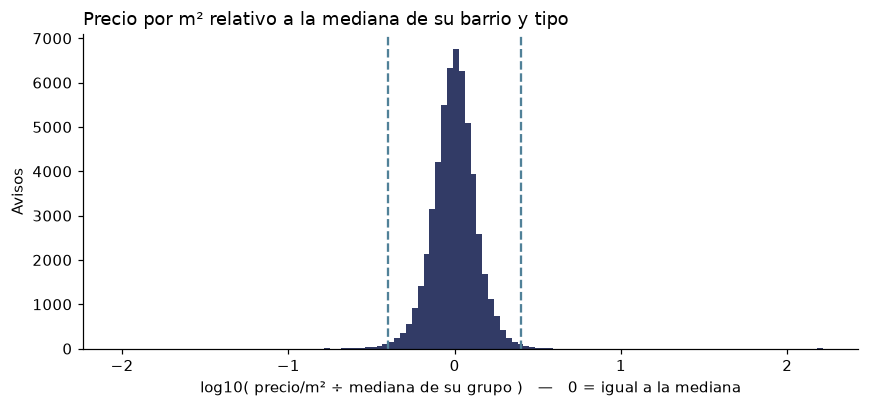

In [33]:
MIN_N_GRUPO = 8      # mismo criterio que el Índice de Subvaluación
UMBRAL_BAJO = 0.40   # PROPUESTA: precio/m² menor al 40% de la mediana de su grupo (equivale a Índice < -0,6)
UMBRAL_ALTO = 2.50   # PROPUESTA: precio/m² mayor a 2,5 veces la mediana de su grupo

ref = df[mask_precio_ok]
mediana_grupo = pd.Series(np.nan, index=df.index)
for cols in [["Barrio_Normalizado", "Tipo_Propiedad", "Tipo_Operacion"], ["Barrio_Normalizado", "Tipo_Operacion"]]:
    g = ref.groupby(cols)["Precio_m2_USD"].agg(["median", "count"])
    g = g[g["count"] >= MIN_N_GRUPO]["median"].rename("mediana")
    candidatos = df[cols].join(g, on=cols)["mediana"]
    nuevos = mediana_grupo.isna() & candidatos.notna()
    mediana_grupo[nuevos] = candidatos[nuevos]

df["Ratio_Precio_m2_vs_Mediana"] = df["Precio_m2_USD"] / mediana_grupo
r = df["Ratio_Precio_m2_vs_Mediana"].dropna()
print("Avisos con ratio calculable:", len(r), "de", len(df))
print("\nPercentiles del ratio (1 = igual a la mediana de su grupo):")
print(r.quantile([.001, .01, .05, .25, .5, .75, .95, .99, .999]).round(2).to_string())

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.hist(np.log10(r), bins=120, color=NAVY)
for u in (UMBRAL_BAJO, UMBRAL_ALTO):
    ax.axvline(np.log10(u), color=TEAL, linestyle="--")
ax.set_xlabel("log10( precio/m² ÷ mediana de su grupo )   —   0 = igual a la mediana")
ax.set_ylabel("Avisos")
ax.set_title("Precio por m² relativo a la mediana de su barrio y tipo", loc="left")
plt.tight_layout()
plt.show()

In [34]:
# Sensibilidad al umbral: ¿cuántos avisos caen, cuántos ya tenían un flag del pipeline, y cuántos llegan a los KPIs?
filas = []
for u in [0.25, 0.30, 0.40, 0.50]:
    m = df["Ratio_Precio_m2_vs_Mediana"] < u
    filas.append({"Umbral bajo": u, "Avisos": int(m.sum()), "% del total": m.mean() * 100,
                  "Ya con Flag_Anomalia_General": int((m & (df.Flag_Anomalia_General == 1)).sum()),
                  "Sin ningún flag previo": int((m & (df.Flag_Anomalia_General == 0)).sum()),
                  "Dentro del filtro p1-p99 (entran a KPIs)": int((m & mask_precio_ok).sum())})
display(pd.DataFrame(filas).set_index("Umbral bajo").round(2))

filas = []
for u in [2.0, 2.5, 3.0, 4.0]:
    m = df["Ratio_Precio_m2_vs_Mediana"] > u
    filas.append({"Umbral alto": u, "Avisos": int(m.sum()), "% del total": m.mean() * 100,
                  "Ya con Flag_Anomalia_General": int((m & (df.Flag_Anomalia_General == 1)).sum()),
                  "Dentro del filtro p1-p99 (entran a KPIs)": int((m & mask_precio_ok).sum())})
display(pd.DataFrame(filas).set_index("Umbral alto").round(2))

df["Flag_Precio_m2_Muy_Bajo"] = (df["Ratio_Precio_m2_vs_Mediana"] < UMBRAL_BAJO).astype(int)
df["Flag_Precio_m2_Muy_Alto"] = (df["Ratio_Precio_m2_vs_Mediana"] > UMBRAL_ALTO).astype(int)
print(f"Con los umbrales elegidos: {df.Flag_Precio_m2_Muy_Bajo.sum()} avisos muy bajos y {df.Flag_Precio_m2_Muy_Alto.sum()} muy altos")

,Avisos,% del total,Ya con Flag_Anomalia_General,Sin ningún flag previo,Dentro del filtro p1-p99 (entran a KPIs)
Umbral bajo,,,,,
0.25,47,0.08,30,17,4
0.30,90,0.16,64,26,22
0.40,319,0.57,212,107,161
0.50,963,1.73,611,352,627


,Avisos,% del total,Ya con Flag_Anomalia_General,Dentro del filtro p1-p99 (entran a KPIs)
Umbral alto,,,,
2.0,726,1.31,487,511
2.5,210,0.38,129,119
3.0,69,0.12,42,26
4.0,24,0.04,12,4


Con los umbrales elegidos: 319 avisos muy bajos y 210 muy altos


In [35]:
# Los casos más extremos hacia abajo, para mirarlos a ojo (y abrir el Link en el navegador)
cols_ver = ["Barrio_Normalizado", "Tipo_Propiedad", "Tipo_Operacion", "Precio_USD", "Superficie_Total_m2",
            "Precio_m2_USD", "Ratio_Precio_m2_vs_Mediana", "Flag_Anomalia_General", "Link"]
pd.set_option("display.max_colwidth", 60)
display(df.nsmallest(12, "Ratio_Precio_m2_vs_Mediana")[cols_ver].round(2))

# ...y los casos intermedios, que son los que el filtro global p1-p99 deja pasar
interm = df[(df.Flag_Precio_m2_Muy_Bajo == 1) & mask_precio_ok & (df.Tipo_Operacion == "Venta")]
print(f"\nVentas con precio/m² muy bajo que SÍ pasan el filtro p1-p99 y entran a los KPIs: {len(interm)}")
display(interm.nsmallest(8, "Ratio_Precio_m2_vs_Mediana")[cols_ver].round(2))

,Barrio_Normalizado,Tipo_Propiedad,Tipo_Operacion,Precio_USD,Superficie_Total_m2,Precio_m2_USD,Ratio_Precio_m2_vs_Mediana,Flag_Anomalia_General,Link
10969,Palermo,Departamento,Alquiler,427.0,3133.0,0.14,0.01,0,https://departamento.mercadolibre.com.ar/MLA-1831463495-...
9341,San Nicolás,Departamento,Venta,82698.0,3290.0,25.14,0.01,0,https://departamento.mercadolibre.com.ar/MLA-1863876469-...
17568,Boedo,Departamento,Venta,55000.0,1786.0,30.80,0.02,1,https://departamento.mercadolibre.com.ar/MLA-1948581087-...
51109,Puerto Madero,PH,Venta,535000.0,5000.0,107.00,0.02,0,https://inmueble.mercadolibre.com.ar/MLA-1680215387-torr...
2799,Belgrano,Departamento,Venta,6570.3,100.0,65.70,0.02,1,https://departamento.mercadolibre.com.ar/MLA-3082829502-...
6369,Palermo,Casa,Venta,6570.3,100.0,65.70,0.03,1,https://casa.mercadolibre.com.ar/MLA-3082828044-compro-t...
55423,Coghlan,PH,Alquiler,75.0,118.0,0.64,0.05,0,https://inmueble.mercadolibre.com.ar/MLA-1642930595-valo...
30752,Puerto Madero,Departamento,Venta,120000.0,400.0,300.00,0.06,0,https://departamento.mercadolibre.com.ar/MLA-1961910855-...
48001,Villa Luro,Casa,Venta,240000.0,3444.0,69.69,0.06,0,https://casa.mercadolibre.com.ar/MLA-1632660869-casa-en-...
3243,San Nicolás,Departamento,Venta,150000.0,1200.0,125.00,0.07,0,https://departamento.mercadolibre.com.ar/MLA-3546329714-...



Ventas con precio/m² muy bajo que SÍ pasan el filtro p1-p99 y entran a los KPIs: 157


,Barrio_Normalizado,Tipo_Propiedad,Tipo_Operacion,Precio_USD,Superficie_Total_m2,Precio_m2_USD,Ratio_Precio_m2_vs_Mediana,Flag_Anomalia_General,Link
30820,Puerto Madero,Departamento,Venta,123000.0,112.57,1092.65,0.21,1,https://departamento.mercadolibre.com.ar/MLA-3726622514-...
30590,Puerto Madero,Departamento,Venta,110000.0,99.00,1111.11,0.21,1,https://departamento.mercadolibre.com.ar/MLA-1913807213-...
32134,Recoleta,Departamento,Venta,295000.0,447.00,659.96,0.23,0,https://departamento.mercadolibre.com.ar/MLA-3717245774-...
664,Villa Devoto,Departamento,Venta,63800.0,100.00,638.00,0.25,0,https://departamento.mercadolibre.com.ar/MLA-3742436692-...
3322,Palermo,Departamento,Venta,114000.0,148.00,770.27,0.25,0,https://departamento.mercadolibre.com.ar/MLA-3588514810-...
27534,Núñez,Departamento,Venta,130000.0,155.00,838.71,0.26,0,https://departamento.mercadolibre.com.ar/MLA-1518290181-...
38607,Villa Crespo,Departamento,Venta,85000.0,132.00,643.94,0.26,1,https://departamento.mercadolibre.com.ar/MLA-1945057923-...
42578,Villa Ortúzar,Departamento,Venta,53000.0,81.00,654.32,0.26,1,https://departamento.mercadolibre.com.ar/MLA-3286834816-...


**Lectura:**
- El ratio está centrado en 1 (mediana 1,00), con colas finas: el 1% más bajo está por debajo de 0,44 y el 1% más alto por encima de 2,10.
- **El filtro global p1–p99 ya saca de los KPIs a casi todos los extremos absolutos**: de los 47 avisos por debajo de 0,25, solo 4 entran. Muchos son errores de superficie evidentes (un alquiler de USD 427 con 3.133 m², una venta de USD 82.698 con 3.290 m², un PH de 5.000 m² en Puerto Madero). Varios no tienen ningún flag: `Flag_Anomalia_General` los dejó pasar. El valor 6.570,3 aparece repetido y equivale a 10.000.000 de pesos al tipo de cambio usado (10.000.000 / 1.522): probable precio cargado en pesos.
- **Lo que el filtro global no ve es lo intermedio.** Con umbral 0,40, 161 de los 319 avisos sí entran a los KPIs, y 107 de los 319 no tenían ningún flag previo. Entre las ventas, los casos más bajos incluyen departamentos de unos 100 m² en Puerto Madero a cerca de USD 1.100/m² (ratio 0,21).
- El umbral es una **PROPUESTA**. La tabla de sensibilidad muestra cuánto cambia: de 90 avisos con 0,30 a 963 con 0,50. Con 0,40 y 2,50 quedan marcados 319 y 210 avisos (0,6% y 0,4% del dataset). No se borra nada.

## 4. Duplicados de contenido

El README informa 0 duplicados por `Item_ID` y por `Link`, y es cierto. Pero un mismo inmueble puede publicarse más de una vez con IDs distintos. Se agrupan avisos con igual barrio, tipo, dirección, precio, superficie y ambientes, y se mira el `Piso` para distinguir **republicaciones** de **unidades distintas** (en un emprendimiento hay deptos idénticos en pisos distintos).

In [36]:
CLAVE_DUP = ["Barrio_Normalizado", "Tipo_Propiedad", "Direccion_Publicada", "Precio_USD", "Superficie_Total_m2", "Ambientes"]
elegibles = df["Direccion_Publicada"].notna() & df["Precio_USD"].notna()

d = df[elegibles].copy()
d["_gid"] = d.groupby(CLAVE_DUP, dropna=False).ngroup()
d["_n"] = d.groupby("_gid")["Item_ID"].transform("size")
d = d[d["_n"] > 1].copy()

d["_pisos_informados"] = d.groupby("_gid")["Piso"].transform("count")
d["_pisos_distintos"] = d.groupby("_gid")["Piso"].transform("nunique")


def nivel(r):
    if r._pisos_informados == 0:
        return "Medio (piso no informado: no se puede distinguir)"
    if r._pisos_distintos > 1:
        return "Bajo (pisos distintos: probables unidades distintas)"
    return "Alto (mismo piso: probable republicación)"


d["Duplicado_Nivel"] = d.apply(nivel, axis=1)
d["_orden"] = d.groupby("_gid").cumcount()

df["Grupo_Duplicado"] = np.nan
df["Duplicado_Nivel"] = pd.Series(dtype="object")
df["Duplicado_Sobrante_Nivel"] = pd.Series(dtype="object")
df.loc[d.index, "Grupo_Duplicado"] = d["_gid"]
df.loc[d.index, "Duplicado_Nivel"] = d["Duplicado_Nivel"]

# DECIDIDO por el grupo (6/10): se marcan TODOS los repetidos, con su nivel de certeza. La primera aparición de cada grupo no se marca.
# Los grupos de nivel Bajo (pisos distintos) no se marcan: son probablemente unidades distintas.
sobrante_alto = (d["_orden"] > 0) & d["Duplicado_Nivel"].str.startswith("Alto")
sobrante_medio = (d["_orden"] > 0) & d["Duplicado_Nivel"].str.startswith("Medio")
df.loc[d.index[sobrante_alto.values], "Duplicado_Sobrante_Nivel"] = "Seguro"
df.loc[d.index[sobrante_medio.values], "Duplicado_Sobrante_Nivel"] = "Probable"
df["Flag_Duplicado_Sobrante"] = df["Duplicado_Sobrante_Nivel"].notna().astype(int)

print(f"Avisos en grupos con más de una publicación: {len(d)} ({len(d)/len(df)*100:.1f}% del dataset) en {d['_gid'].nunique()} grupos")
print("\nGrupos según nivel de certeza:")
print(d.groupby("_gid")["Duplicado_Nivel"].first().value_counts().to_string())
print(f"\nFlag_Duplicado_Sobrante = 1: {int(df.Flag_Duplicado_Sobrante.sum())} avisos ({int(sobrante_alto.sum())} \"Seguro\" + {int(sobrante_medio.sum())} \"Probable\")")
print("\nTipo de vendedor en los avisos duplicados:", d["Tipo_Vendedor"].value_counts().to_dict())
mismo_titulo = d.groupby("_gid")["Titulo"].nunique().eq(1).mean() * 100
print(f"Grupos donde el título es idéntico en todos los avisos: {mismo_titulo:.0f}%")

Avisos en grupos con más de una publicación: 4957 (8.9% del dataset) en 2218 grupos

Grupos según nivel de certeza:
Duplicado_Nivel
Medio (piso no informado: no se puede distinguir)       1077
Alto (mismo piso: probable republicación)                942
Bajo (pisos distintos: probables unidades distintas)     199

Flag_Duplicado_Sobrante = 1: 2401 avisos (1106 "Seguro" + 1295 "Probable")

Tipo de vendedor en los avisos duplicados: {'Inmobiliaria': 4888, 'normal': 68}
Grupos donde el título es idéntico en todos los avisos: 69%


**Lectura:** 4.957 avisos (8,9% del dataset) comparten barrio, tipo, dirección, precio, superficie y ambientes con otro aviso, en 2.218 grupos. El 98,6% lo publica una inmobiliaria y en el 69% de los grupos el título es idéntico. No es un problema del scraping (cada fila tiene `Item_ID` y `Link` propios): es el mismo inmueble publicado más de una vez.

No todos son republicaciones. En 942 grupos el piso informado coincide (**republicación probable**); en 199 los pisos difieren (**unidades distintas**, típico de un emprendimiento); y en 1.077 el piso no está informado y no se puede distinguir. **Decisión del grupo (6/10):** se marcan todos los repetidos con su nivel de certeza, en `Duplicado_Sobrante_Nivel`: **Seguro** (mismo piso, 1.106 avisos) y **Probable** (piso no informado, 1.295 avisos). La primera aparición de cada grupo no se marca, y los grupos de pisos distintos tampoco. `Flag_Duplicado_Sobrante` vale 1 para los dos niveles (2.401 avisos). No se borra ninguno.

## 5. Impacto sobre el ranking de oportunidades

El `Score_Oportunidad` de `Unificacion.ipynb` no se guarda en el CSV: vive solo en el notebook. Se lo replica acá (mismas fórmulas, pesos 0,5 / 0,5) para medir si los problemas de las secciones 2 a 4 lo afectan.

In [37]:
def ranking(d, excluir=None):
    m = (d.Tipo_Operacion == "Venta") & d.Rentabilidad_Neta_Zona.notna() & d.Indice_Subvaluacion.notna()
    if excluir is not None:
        m &= ~excluir
    s = d[m].copy()
    norm01 = lambda x: (x - x.min()) / (x.max() - x.min())
    s["R"], s["S"] = norm01(s["Rentabilidad_Neta_Zona"]), norm01(-s["Indice_Subvaluacion"])
    s["Factor_Confianza"] = np.where(
        (s.Flag_Faltantes_Criticos == 1) | (s.Flag_Coordenadas_Anomalas == 1), 0.0,
        np.where(s.Flag_Anomalia_General == 0, 1.0, 0.6))
    s["Score_Oportunidad"] = (0.5 * s["R"] + 0.5 * s["S"]) * s["Factor_Confianza"] * 100
    return s[s.Factor_Confianza > 0].sort_values("Score_Oportunidad", ascending=False)


rk = ranking(df)
n_ventas = (df.Tipo_Operacion == "Venta").sum()
print(f"Avisos rankeados: {len(rk)} de {n_ventas} ventas ({len(rk)/n_ventas*100:.0f}%) — el resto no tiene rentabilidad de zona o tiene Factor_Confianza 0")

top100 = rk.head(100)
print("\nTop 100 por barrio:", top100["Barrio_Normalizado"].value_counts().to_dict())
print("Top 100 por tipo y ambientes:", top100.groupby(["Tipo_Propiedad", "Ambientes_Agrupado"]).size().to_dict())
print("Filas del top 100 que son duplicados sobrantes:", top100["Duplicado_Sobrante_Nivel"].value_counts().to_dict())
print("Filas del top 100 con precio/m² muy bajo:", int(top100["Flag_Precio_m2_Muy_Bajo"].sum()))

# ¿Dónde caen los avisos con precio/m² muy bajo?
rk["_pos"] = np.arange(1, len(rk) + 1)
extremos = rk[rk.Flag_Precio_m2_Muy_Bajo == 1]
print(f"\nAvisos con precio/m² muy bajo dentro del ranking: {len(extremos)}. Posición mediana: {int(extremos._pos.median())} de {len(rk)}; mejor posición: {int(extremos._pos.min())}")

Avisos rankeados: 35771 de 50639 ventas (71%) — el resto no tiene rentabilidad de zona o tiene Factor_Confianza 0

Top 100 por barrio: {'Núñez': 60, 'Monserrat': 34, 'Villa Devoto': 5, 'Barracas': 1}
Top 100 por tipo y ambientes: {('Casa', '4+'): 5, ('Departamento', '3'): 34, ('Departamento', '4+'): 60, ('PH', '2'): 1}
Filas del top 100 que son duplicados sobrantes: {'Probable': 4, 'Seguro': 3}
Filas del top 100 con precio/m² muy bajo: 0

Avisos con precio/m² muy bajo dentro del ranking: 97. Posición mediana: 6666 de 35771; mejor posición: 158


In [38]:
# Ranking "limpio": sin avisos de precio/m² muy bajo ni duplicados SEGUROS (los "probables" se dejan: pueden ser unidades distintas)
excluir = (df.Flag_Precio_m2_Muy_Bajo == 1) | (df.Duplicado_Sobrante_Nivel == "Seguro")
rk_limpio = ranking(df, excluir=excluir)
top100_limpio = rk_limpio.head(100)

print(f"Avisos que salen del ranking por estos flags: {len(rk) - len(rk_limpio)}")
print(f"Avisos rankeados: {len(rk)} -> {len(rk_limpio)}")
print("Coincidencia entre ambos top 100:", len(set(top100.index) & set(top100_limpio.index)), "de 100")
print("Top 100 limpio por barrio:", top100_limpio["Barrio_Normalizado"].value_counts().to_dict())

Avisos que salen del ranking por estos flags: 912
Avisos rankeados: 35771 -> 34859
Coincidencia entre ambos top 100: 96 de 100
Top 100 limpio por barrio: {'Núñez': 56, 'Monserrat': 38, 'Villa Devoto': 5, 'Barracas': 1}


**Lectura:** conviene separar dos cosas.

**1. Los problemas de datos casi no mueven el ranking.** Los precios muy bajos en contexto no llegan al top: ninguno de los 100 primeros está marcado, y los 97 que sí están en el ranking caen en una posición mediana de 5.943 sobre 35.419 (la mejor es la 117). Los duplicados sobrantes dentro del top 100 son 7: 3 seguros y 4 probables. Sacar los precios muy bajos y los duplicados seguros (912 avisos) deja 97 de los 100 primeros iguales. *(Esto corrige una advertencia previa de este trabajo: se esperaba que los precios sospechosos dominaran el top, y los datos dicen otra cosa.)*

**2. El ranking sí tiene una concentración estructural.** El top 100 está formado por solo dos celdas de zona: 59 avisos de Núñez (Departamento 4+) y 41 de Monserrat (Departamento 3), y ninguno de otro barrio. La causa es de diseño: `Rentabilidad_Neta_Zona` es una constante por celda y pesa el 50% del Score, así que las celdas más rentables ocupan el podio completo y la subvaluación individual solo ordena dentro de ellas. Para el objetivo de "priorizar avisos concretos", esto es una limitación más relevante que los outliers. Además, solo se rankea el 70% de las ventas (35.419 de 50.639): el resto no tiene rentabilidad de zona.

## 6. Resumen de decisiones

In [39]:
resumen = pd.DataFrame([
    ("Tipo_Alquiler, Estado_Inmueble", "Faltantes disfrazados como \"Desconocido\" (90,8% de los alquileres; ~75% del dataset)", "Columnas `_Limpio` con nulos reales (2.6.1). No filtrar por tradicional/temporario; usar Estado solo en el subconjunto informado."),
    ("Piso, Cantidad_Pisos_Edificio, Departamentos_Por_Piso", "No aplica a casas/PH; hueco real en departamentos (41% a 47%)", "Usar solo en departamentos y con cautela (2.6.4); no imputar."),
    ("Subtipo_Propiedad", "Mayormente no informado (72,8%)", "Cobertura escasa: candidata a descartar."),
    ("Superficie_Balcon_m2", "El nulo mezcla \"no tiene\" y \"no informó\"; Balcon = 0 no es confiable (incluye \"no detectado\")", "Se mantiene sin imputar (`BALCON_0_ES_NO_TIENE = False`); `Flag_Balcon_Sin_Dato`. PENDIENTE: el grupo no lo discutió por separado."),
    ("Cocheras", "En PH el \"no tiene\" está como nulo; en Casa/Depto como 0. El test de precios no discrimina", "DECIDIDO (6/10): nulo = no tiene; se imputa 0 en PH (`IMPUTAR_COCHERAS_PH = True`). Queda marcado en `Flag_Cocheras_PH_Sin_Dato`."),
    ("Orientacion, Disposicion, Bauleras", "No informado", "Ver la tabla de cobertura útil (2.6.4); dejar como nulo."),
    ("Expensas_USD", "Hueco real (5%) + 23.820 ceros sospechosos. En departamentos el 0 es un faltante disfrazado; en casas y PH es lo normal", "`Expensas_USD_Limpio` (0 -> nulo solo en departamentos, 2.6.6). Usarla en vez de `Expensas_USD` en todo análisis descriptivo. DECIDIDO (6/10): `Expensas_USD_Imputada` completa los departamentos con la mediana de su celda; `Flag_Expensas_Imputada`."),
    ("Antiguedad", "~35% en 0; 11.132 sin estado que lo confirme", "El test de precios indica que son mayormente nuevos: no se tocan. `Flag_Antiguedad_Cero_Sin_Estado` (2.6.7)."),
    ("Barrio_Normalizado", "133 avisos sin barrio, todos con coordenadas", "`Barrio_Completo` por vecinos más cercanos, validado (2.6.8); `Flag_Barrio_Por_Vecinos`."),
    ("Rentabilidad_Neta_Zona", "Estructural por falta de alquileres en la celda; 11 de 48 barrios sin cobertura", "DECIDIDO (6/10): H1 se evalúa solo en los barrios con rentabilidad original. `Rentabilidad_Neta_Cascada` queda como prueba de robustez (2.6.5)."),
    ("Precio/m² fuera de contexto", "Outlier contextual no detectado por el filtro global", "DECIDIDO (6/10): flag con umbrales 0,40 / 2,50; no se borra."),
    ("Duplicados de contenido", "Republicaciones probables con distinto Item_ID", "DECIDIDO (6/10): se marcan todos con nivel (`Duplicado_Sobrante_Nivel`: Seguro / Probable); el nivel Bajo no se marca; no se borra."),
], columns=["Variable / problema", "Diagnóstico", "Tratamiento propuesto"])
pd.set_option("display.max_colwidth", 130)
display(resumen)

,Variable / problema,Diagnóstico,Tratamiento propuesto
0,"Tipo_Alquiler, Estado_Inmueble","Faltantes disfrazados como ""Desconocido"" (90,8% de los alquileres; ~75% del dataset)",Columnas `_Limpio` con nulos reales (2.6.1). No filtrar por tradicional/temporario; usar Estado solo en el subconjunto informado.
1,"Piso, Cantidad_Pisos_Edificio, Departamentos_Por_Piso",No aplica a casas/PH; hueco real en departamentos (41% a 47%),Usar solo en departamentos y con cautela (2.6.4); no imputar.
2,Subtipo_Propiedad,"Mayormente no informado (72,8%)",Cobertura escasa: candidata a descartar.
3,Superficie_Balcon_m2,"El nulo mezcla ""no tiene"" y ""no informó""; Balcon = 0 no es confiable (incluye ""no detectado"")",Se mantiene sin imputar (`BALCON_0_ES_NO_TIENE = False`); `Flag_Balcon_Sin_Dato`. PENDIENTE: el grupo no lo discutió por separ...
4,Cocheras,"En PH el ""no tiene"" está como nulo; en Casa/Depto como 0. El test de precios no discrimina",DECIDIDO (6/10): nulo = no tiene; se imputa 0 en PH (`IMPUTAR_COCHERAS_PH = True`). Queda marcado en `Flag_Cocheras_PH_Sin_Dato`.
5,"Orientacion, Disposicion, Bauleras",No informado,Ver la tabla de cobertura útil (2.6.4); dejar como nulo.
6,Expensas_USD,Hueco real (5%) + 23.820 ceros sospechosos. En departamentos el 0 es un faltante disfrazado; en casas y PH es lo normal,"`Expensas_USD_Limpio` (0 -> nulo solo en departamentos, 2.6.6). Usarla en vez de `Expensas_USD` en todo análisis descriptivo. ..."
7,Antiguedad,~35% en 0; 11.132 sin estado que lo confirme,El test de precios indica que son mayormente nuevos: no se tocan. `Flag_Antiguedad_Cero_Sin_Estado` (2.6.7).
8,Barrio_Normalizado,"133 avisos sin barrio, todos con coordenadas","`Barrio_Completo` por vecinos más cercanos, validado (2.6.8); `Flag_Barrio_Por_Vecinos`."
9,Rentabilidad_Neta_Zona,Estructural por falta de alquileres en la celda; 11 de 48 barrios sin cobertura,DECIDIDO (6/10): H1 se evalúa solo en los barrios con rentabilidad original. `Rentabilidad_Neta_Cascada` queda como prueba de ...


## 7. Guardado

Se agregan solo columnas nuevas. Antes de escribir se verifica que no cambió el número de filas ni ningún valor de las columnas originales.

In [40]:
COLUMNAS_NUEVAS = ["Motivo_Rentabilidad_Nula", "Flag_Rentabilidad_No_Calculable",
                   "Estado_Inmueble_Limpio", "Tipo_Alquiler_Limpio", "Superficie_Balcon_m2_Tratada", "Flag_Balcon_Sin_Dato",
                   "Cocheras_Tratada", "Flag_Cocheras_PH_Sin_Dato", "Rentabilidad_Neta_Cascada", "Nivel_Rentabilidad_Cascada",
                   "Expensas_USD_Limpio", "Expensas_USD_Imputada", "Flag_Expensas_Imputada", "Flag_Antiguedad_Cero_Sin_Estado", "Barrio_Completo", "Flag_Barrio_Por_Vecinos",
                   "Ratio_Precio_m2_vs_Mediana", "Flag_Precio_m2_Muy_Bajo", "Flag_Precio_m2_Muy_Alto",
                   "Grupo_Duplicado", "Duplicado_Nivel", "Duplicado_Sobrante_Nivel", "Flag_Duplicado_Sobrante"]

original = pd.read_csv(RUTA_ENTRADA, low_memory=False)
assert len(df) == len(original), "Cambió la cantidad de filas"
assert list(df.columns[:len(COLUMNAS_ORIGINALES)]) == COLUMNAS_ORIGINALES, "Cambió el orden o nombre de columnas originales"
assert df[COLUMNAS_ORIGINALES].equals(original[COLUMNAS_ORIGINALES]), "Se modificó algún valor original"

df.to_csv(RUTA_SALIDA, index=False)
print(f"Guardado: {RUTA_SALIDA.relative_to(RAIZ)} | {len(df)} filas | {len(COLUMNAS_NUEVAS)} columnas nuevas:")
print(", ".join(COLUMNAS_NUEVAS))

Guardado: data/processed/dataframe_limpio.csv | 55582 filas | 23 columnas nuevas:
Motivo_Rentabilidad_Nula, Flag_Rentabilidad_No_Calculable, Estado_Inmueble_Limpio, Tipo_Alquiler_Limpio, Superficie_Balcon_m2_Tratada, Flag_Balcon_Sin_Dato, Cocheras_Tratada, Flag_Cocheras_PH_Sin_Dato, Rentabilidad_Neta_Cascada, Nivel_Rentabilidad_Cascada, Expensas_USD_Limpio, Expensas_USD_Imputada, Flag_Expensas_Imputada, Flag_Antiguedad_Cero_Sin_Estado, Barrio_Completo, Flag_Barrio_Por_Vecinos, Ratio_Precio_m2_vs_Mediana, Flag_Precio_m2_Muy_Bajo, Flag_Precio_m2_Muy_Alto, Grupo_Duplicado, Duplicado_Nivel, Duplicado_Sobrante_Nivel, Flag_Duplicado_Sobrante


## Decisiones del grupo (chat del 6/10)

**Cerradas** (ya aplicadas en este notebook):
1. **H1.** Se evalúa solo en los barrios con rentabilidad calculada en el nivel original. Quedan afuera Parque Avellaneda (0% de cobertura) y parcialmente Mataderos (41%); Flores tiene 88% y Palermo, Recoleta y Belgrano entre 94% y 98%. La cascada (2.6.5) queda como prueba de robustez.
2. **Umbral de precio por m².** 0,40 / 2,50, como flag (3.2).
3. **Duplicados.** Se marcan todos con nivel Seguro / Probable (sección 4).
4. **Cocheras en PH.** Nulo = no tiene: se imputa 0 y queda marcado (2.6.3).
5. **Alquiler tradicional vs. temporario.** Resultados en dos versiones (con todos y solo con los confirmados como tradicionales) y revisión manual de una muestra de los 30 alquileres de la celda Núñez Departamento 4+. *La revisión manual todavía no está hecha.*
8. **Expensas de departamentos.** Se imputan con la mediana de su celda y quedan marcadas (2.6.6b).

**Abiertas:**
- **Balcón (2.6.2).** El grupo no lo discutió por separado y la evidencia propia va en contra (el 19,6% de los departamentos con `Balcon = 0` informa superficie). Se mantiene sin imputar (`BALCON_0_ES_NO_TIENE = False`) hasta confirmarlo.
- **Expensas de PH y casas en la rentabilidad (7).** El grupo decidió recalcular incluyendo los ceros. Es un cambio de una celda en `Unificacion.ipynb` (el parche está preparado y verificado). Cuando se integre, hay que poner `UNIFICACION_CUENTA_CEROS_PH_CASA = True` en 2.4 y volver a correr este notebook: algunas cifras de las lecturas cambian (por ejemplo, el top 100 pasa de 2 a 4 barrios, porque entran 5 casas de Villa Devoto y 1 PH de Barracas).
- **Ranking (6).** (a) Armar un ranking alternativo para compararlos: ¿quién? (b) Guardar el `Score_Oportunidad` en el CSV. (c) Corregir los pesos del documento de propuesta (0,4 / 0,4) para alinearlos con el código y el README (0,5 / 0,5).
- **H1.** Definir qué barrios son "sur/oeste" y cuáles "norte premium": la hipótesis solo da ejemplos.
- **Archivo de salida.** `dataframe_limpio.csv` pesa unos 47 MB, parecido a `dataframefinal.csv`. Está en `.gitignore`; falta decidir si se versiona o se regenera ejecutando los notebooks.